In [1]:
import pandas as pd
import numpy as np


calendar_df = pd.read_csv("dataset/calendar.csv")
sales_validation_df = pd.read_csv("dataset/sales_train_validation.csv")
sales_evaluation_df = pd.read_csv("dataset/sales_train_evaluation.csv")
sell_prices_df = pd.read_csv("dataset/sell_prices.csv")
sample_submission_df = pd.read_csv("dataset/sample_submission.csv")

In [2]:
calendar_df.head()


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [3]:
sales_validation_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [4]:
sales_evaluation_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [5]:
sell_prices_df.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [6]:
sample_submission_df.head()

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print("Number of Stores:", sales_validation_df["store_id"].nunique())
print("Stores:")
print(sales_validation_df["store_id"].unique())

print("\nNumber of Categories:", sales_validation_df["cat_id"].nunique())
print("Categories:")
print(sales_validation_df["cat_id"].unique())

print("\nNumber of States:", sales_validation_df["state_id"].nunique())
print("States:")
print(sales_validation_df["state_id"].unique())

Number of Stores: 10
Stores:
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']

Number of Categories: 3
Categories:
['HOBBIES' 'HOUSEHOLD' 'FOODS']

Number of States: 3
States:
['CA' 'TX' 'WI']


In [8]:
sales_cols = [col for col in sales_validation_df.columns if col.startswith("d_")]

print("Number of daily demand columns:", len(sales_cols))
print(sales_cols[:5])
print(sales_cols[-5:])

Number of daily demand columns: 1913
['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


Convert Wide Format to Long Format
Current format:
30,490 rows × 1,913 day columns
We need:
Date
Store
Category
Demand
Use pd.melt().

In [9]:
sales_long = pd.melt(
    sales_validation_df,
    id_vars=[
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id"
    ],
    value_vars=sales_cols,
    var_name="d",
    value_name="demand"
)

sales_long.head()

,item_id,dept_id,cat_id,store_id,state_id,d,demand
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [10]:
print(sales_long.shape)

(58327370, 7)


---
store_category_daily = (
    sales_long
    .groupby(
        ["store_id", "cat_id", "d"],
        as_index=False
    )["demand"]
    .sum()
)

store_category_daily.head()Aggregate to Store × Category × Day
Why?

Forecasting all 30,490 item-level series is unnecessary and computationally expensive.

Instead:

Store × Category × Day

Aggregate demand.

In [11]:
store_category_daily = (
    sales_long
    .groupby(
        ["store_id", "cat_id", "d"],
        as_index=False
    )["demand"]
    .sum()
)

store_category_daily.head()

,store_id,cat_id,d,demand
0,CA_1,FOODS,d_1,3239
1,CA_1,FOODS,d_10,2446
2,CA_1,FOODS,d_100,2096
3,CA_1,FOODS,d_1000,2126
4,CA_1,FOODS,d_1001,2827


In [12]:
print(store_category_daily.shape)

(57390, 4)


---
Prepare Calendar Table

Convert date column to datetime.Prepare Calendar Table

Convert date column to datetime.

In [13]:
calendar_df["date"] = pd.to_datetime(
    calendar_df["date"]
)

calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[ns]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   object        
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   object        
 7   event_name_1  162 non-null    object        
 8   event_type_1  162 non-null    object        
 9   event_name_2  5 non-null      object        
 10  event_type_2  5 non-null      object        
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
dtypes: datetime64[ns](1), int64(7), object(6)
memory usage: 215.5+ KB


In [14]:
calendar_features = calendar_df[
    [
        "d",
        "date",
        "weekday",
        "wday",
        "month",
        "year",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
        "snap_CA",
        "snap_TX",
        "snap_WI"
    ]
]

---
Merge Calendar Features

Join using:

d

which exists in both datasets.

In [15]:
store_category_daily = store_category_daily.merge(
    calendar_features,
    on="d",
    how="left"
)

store_category_daily.head()

,store_id,cat_id,d,demand,date,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,CA_1,FOODS,d_1,3239,2011-01-29,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,CA_1,FOODS,d_10,2446,2011-02-07,Monday,3,2,2011,NaN,NaN,NaN,NaN,1,1,0
2,CA_1,FOODS,d_100,2096,2011-05-08,Sunday,2,5,2011,Mother's day,Cultural,NaN,NaN,1,0,1
3,CA_1,FOODS,d_1000,2126,2013-10-24,Thursday,6,10,2013,NaN,NaN,NaN,NaN,0,0,0
4,CA_1,FOODS,d_1001,2827,2013-10-25,Friday,7,10,2013,NaN,NaN,NaN,NaN,0,0,0


In [16]:
print(store_category_daily.shape)

(57390, 16)


Data Quality Checks
Missing Values

In [17]:
missing_values = (
    store_category_daily
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_values.head(20))

event_name_2    57270
event_type_2    57270
event_name_1    52770
event_type_1    52770
store_id            0
cat_id              0
d                   0
demand              0
date                0
weekday             0
wday                0
month               0
year                0
snap_CA             0
snap_TX             0
snap_WI             0
dtype: int64


In [18]:
#Duplicate Records
print(
    "Duplicates:",
    store_category_daily.duplicated().sum()
)

Duplicates: 0


In [19]:
#Categories
print(
    store_category_daily["cat_id"].value_counts()
)

cat_id
FOODS        19130
HOBBIES      19130
HOUSEHOLD    19130
Name: count, dtype: int64


In [20]:
#Stores
print(
    store_category_daily["store_id"].value_counts()
)

store_id
CA_1    5739
CA_2    5739
CA_3    5739
CA_4    5739
TX_1    5739
TX_2    5739
TX_3    5739
WI_1    5739
WI_2    5739
WI_3    5739
Name: count, dtype: int64


---
Save Master Dataset

This becomes the main dataset used in all later phases.

In [21]:
store_category_daily["d_num"] = (
    store_category_daily["d"]
    .str.replace("d_", "", regex=False)
    .astype(int)
)

store_category_daily = (
    store_category_daily
    .sort_values(
        ["store_id", "cat_id", "d_num"]
    )
    .reset_index(drop=True)
)

store_category_daily.head()

,store_id,cat_id,d,demand,date,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,d_num
0,CA_1,FOODS,d_1,3239,2011-01-29,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,1
1,CA_1,FOODS,d_2,3137,2011-01-30,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0,2
2,CA_1,FOODS,d_3,2008,2011-01-31,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0,3
3,CA_1,FOODS,d_4,2258,2011-02-01,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0,4
4,CA_1,FOODS,d_5,2032,2011-02-02,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1,5


In [22]:
store_category_daily["event_name_1"] = (
    store_category_daily["event_name_1"]
    .fillna("No_Event")
)

store_category_daily["event_type_1"] = (
    store_category_daily["event_type_1"]
    .fillna("No_Event")
)

store_category_daily["event_name_2"] = (
    store_category_daily["event_name_2"]
    .fillna("No_Event")
)

store_category_daily["event_type_2"] = (
    store_category_daily["event_type_2"]
    .fillna("No_Event")
)

store_category_daily["is_event"] = (
    store_category_daily["event_name_1"] != "No_Event"
).astype(int)

In [23]:
store_category_daily.to_csv(
    "store_category_daily.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [24]:
store_category_daily.isnull().sum().sort_values(ascending=False)

store_id        0
cat_id          0
d_num           0
snap_WI         0
snap_TX         0
snap_CA         0
event_type_2    0
event_name_2    0
event_type_1    0
event_name_1    0
year            0
month           0
wday            0
weekday         0
date            0
demand          0
d               0
is_event        0
dtype: int64

In [25]:
sell_prices_df.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


Create Item → Category Mapping

From sales table:

In [26]:
item_category_map = (
    sales_validation_df[
        ["item_id", "cat_id"]
    ]
    .drop_duplicates()
)

item_category_map.head()

,item_id,cat_id
0,HOBBIES_1_001,HOBBIES
1,HOBBIES_1_002,HOBBIES
2,HOBBIES_1_003,HOBBIES
3,HOBBIES_1_004,HOBBIES
4,HOBBIES_1_005,HOBBIES


In [27]:
#Merge into Price Table

sell_prices_enriched = sell_prices_df.merge(
    item_category_map,
    on="item_id",
    how="left"
)

sell_prices_enriched.head()

,store_id,item_id,wm_yr_wk,sell_price,cat_id
0,CA_1,HOBBIES_1_001,11325,9.58,HOBBIES
1,CA_1,HOBBIES_1_001,11326,9.58,HOBBIES
2,CA_1,HOBBIES_1_001,11327,8.26,HOBBIES
3,CA_1,HOBBIES_1_001,11328,8.26,HOBBIES
4,CA_1,HOBBIES_1_001,11329,8.26,HOBBIES


---
Aggregate to Store × Category × Week

Remember:

Our forecasting level is:

Store × Category

Therefore we need:

Average Category Price

In [28]:
category_prices = (
    sell_prices_enriched
    .groupby(
        ["store_id", "cat_id", "wm_yr_wk"],
        as_index=False
    )
    .agg(
        avg_category_price=("sell_price", "mean")
    )
)

category_prices.head()

,store_id,cat_id,wm_yr_wk,avg_category_price
0,CA_1,FOODS,11101,3.149220
1,CA_1,FOODS,11102,3.153394
2,CA_1,FOODS,11103,3.129630
3,CA_1,FOODS,11104,3.123212
4,CA_1,FOODS,11105,3.125868


Why Mean Price?

Suppose:

FOODS

contains:

Milk = $2
Bread = $4
Juice = $3

Category-level demand should see a representative category price.

Mean is a reasonable proxy.

---
Step 2.3 — Bring Week Information Into Master Dataset

Your master dataset currently contains:

d
date

but not:

wm_yr_wk

which exists in calendar.

---

In [29]:
week_mapping = calendar_df[
    ["d", "wm_yr_wk"]
]

In [30]:
store_category_daily = (
    store_category_daily
    .merge(
        week_mapping,
        on="d",
        how="left"
    )
)

In [31]:
store_category_daily[
    ["d", "wm_yr_wk"]
].head()

,d,wm_yr_wk
0,d_1,11101
1,d_2,11101
2,d_3,11101
3,d_4,11101
4,d_5,11101


Step 2.4 — Merge Prices Into Master Dataset

Now both datasets have:

store_id
cat_id
wm_yr_wk

In [32]:
store_category_daily = (
    store_category_daily
    .merge(
        category_prices,
        on=[
            "store_id",
            "cat_id",
            "wm_yr_wk"
        ],
        how="left"
    )
)

In [33]:
store_category_daily[
    "avg_category_price"
].isnull().sum()

0

Step 2.6 — Create Price Features

These are important demand drivers.

Feature 1: Price Change %

For each Store × Category:

In [34]:
store_category_daily = (
    store_category_daily
    .sort_values(
        ["store_id", "cat_id", "date"]
    )
)

In [35]:
store_category_daily[
    "price_change_pct"
] = (
    store_category_daily
    .groupby(
        ["store_id", "cat_id"]
    )["avg_category_price"]
    .pct_change()
)

In [36]:
#Feature 2: 4-Week Rolling Average Price

store_category_daily[
    "rolling_price_28"
] = (
    store_category_daily
    .groupby(
        ["store_id", "cat_id"]
    )["avg_category_price"]
    .transform(
        lambda x:
        x.rolling(28, min_periods=1).mean()
    )
)

In [37]:
#Feature 3: Price Momentum

store_category_daily[
    "price_momentum"
] = (
    store_category_daily[
        "avg_category_price"
    ]
    /
    store_category_daily[
        "rolling_price_28"
    ]
)

Interpretation
>1

Current price higher than usual.

< 1

Current price lower than usual.

In [38]:
store_category_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57390 entries, 0 to 57389
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   store_id            57390 non-null  object        
 1   cat_id              57390 non-null  object        
 2   d                   57390 non-null  object        
 3   demand              57390 non-null  int64         
 4   date                57390 non-null  datetime64[ns]
 5   weekday             57390 non-null  object        
 6   wday                57390 non-null  int64         
 7   month               57390 non-null  int64         
 8   year                57390 non-null  int64         
 9   event_name_1        57390 non-null  object        
 10  event_type_1        57390 non-null  object        
 11  event_name_2        57390 non-null  object        
 12  event_type_2        57390 non-null  object        
 13  snap_CA             57390 non-null  int64     

In [39]:
# Save latest cleaned dataset

store_category_daily.to_csv(
    "store_category_daily_enriched.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


# Phase 3 — Exploratory Data Analysis (EDA)

Goal:

Understand the major drivers of demand before building forecasting features.

Business Questions:

1. How does demand evolve through time?
2. Is demand seasonal?
3. Which stores and categories generate the most demand?
4. Do events increase demand?
5. Do SNAP benefits influence demand?
6. Do prices influence demand?

## 3.1 Overall Demand Trend

Aggregate demand across all stores and categories.

This helps identify:

- Growth trends
- Structural changes
- Major spikes
- Demand stability

In [40]:
daily_demand = (
    store_category_daily
    .groupby("date", as_index=False)
    ["demand"]
    .sum()
)

daily_demand.head()

,date,demand
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146


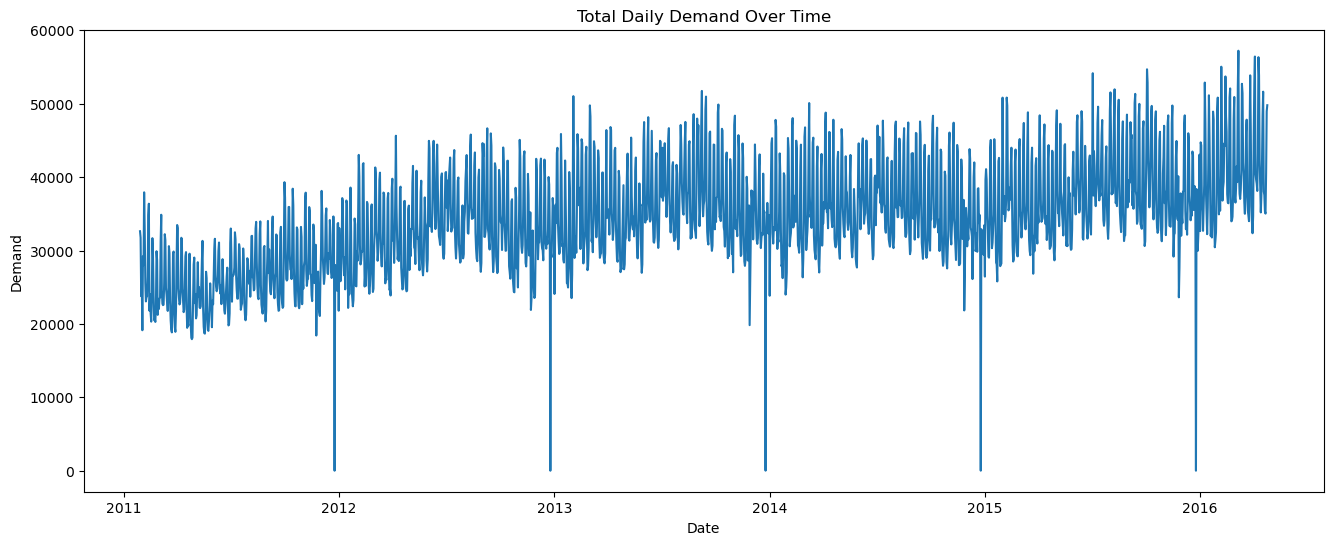

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,6))

sns.lineplot(
    data=daily_demand,
    x="date",
    y="demand"
)

plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()

## 3.2 Demand Distribution

Understanding the demand distribution helps identify:

- Skewness
- Outliers
- Forecasting difficulty

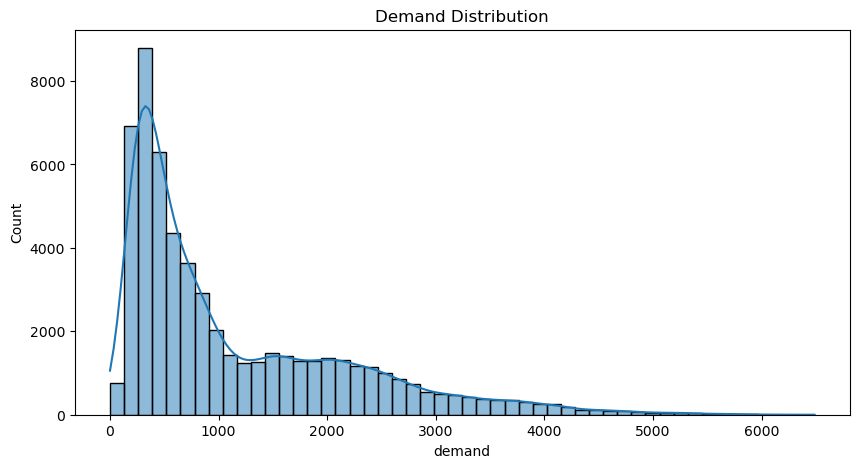

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(
    store_category_daily["demand"],
    bins=50,
    kde=True
)

plt.title("Demand Distribution")

plt.show()

In [43]:
store_category_daily["demand"].describe()

count    57390.000000
mean      1144.718749
std       1049.785911
min          0.000000
25%        354.000000
50%        702.000000
75%       1734.000000
max       6488.000000
Name: demand, dtype: float64

## 3.3 Demand by Category

Determine which product categories contribute most demand.

In [44]:
category_summary = (
    store_category_daily
    .groupby("cat_id")
    .agg(
        total_demand=("demand","sum"),
        avg_demand=("demand","mean")
    )
    .reset_index()
)

category_summary

,cat_id,total_demand,avg_demand
0,FOODS,45089939,2357.027653
1,HOBBIES,6124800,320.167277
2,HOUSEHOLD,14480670,756.961317


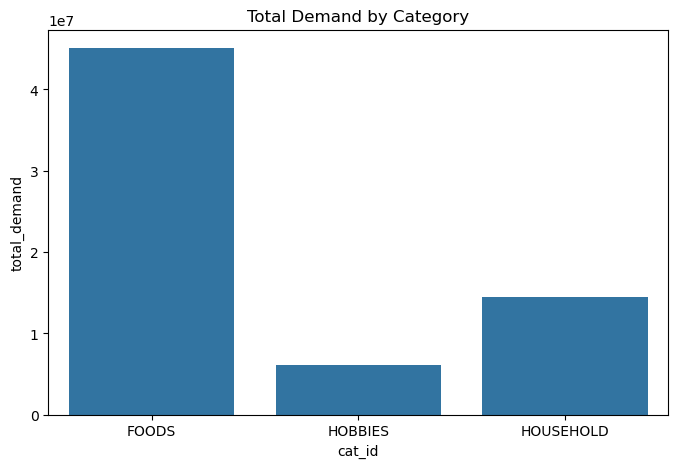

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_summary,
    x="cat_id",
    y="total_demand"
)

plt.title("Total Demand by Category")

plt.show()

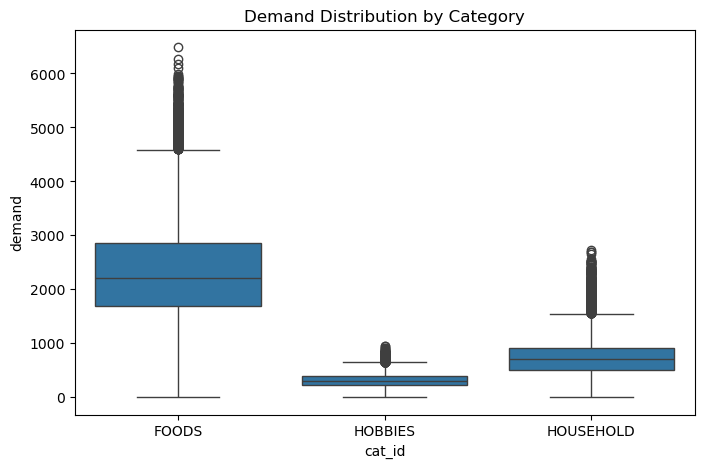

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=store_category_daily,
    x="cat_id",
    y="demand"
)

plt.title("Demand Distribution by Category")

plt.show()

## 3.4 Demand by Store

Identify the largest demand generating stores.

In [47]:
store_summary = (
    store_category_daily
    .groupby("store_id")
    .agg(
        total_demand=("demand","sum")
    )
    .reset_index()
    .sort_values(
        "total_demand",
        ascending=False
    )
)

store_summary.head()

,store_id,total_demand
2,CA_3,11188180
0,CA_1,7698216
5,TX_2,7214384
8,WI_2,6544012
9,WI_3,6427782


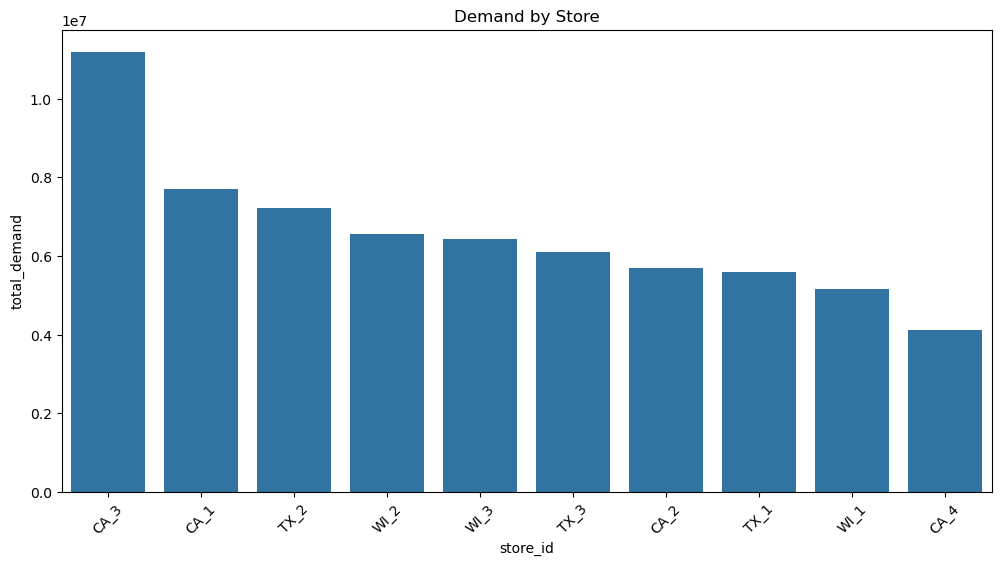

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=store_summary,
    x="store_id",
    y="total_demand"
)

plt.title("Demand by Store")

plt.xticks(rotation=45)

plt.show()

## 3.5 Weekly Seasonality

Retail demand often varies by day of week.

We examine average demand by weekday.

In [49]:
weekday_demand = (
    store_category_daily
    .groupby("weekday")["demand"]
    .mean()
    .reset_index()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand["weekday"] = pd.Categorical(
    weekday_demand["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_demand = weekday_demand.sort_values("weekday")

weekday_demand

,weekday,demand
1,Monday,1095.098901
5,Tuesday,1012.292674
6,Wednesday,1000.334066
4,Thursday,1006.833578
0,Friday,1140.866178
2,Saturday,1384.896472
3,Sunday,1371.000730


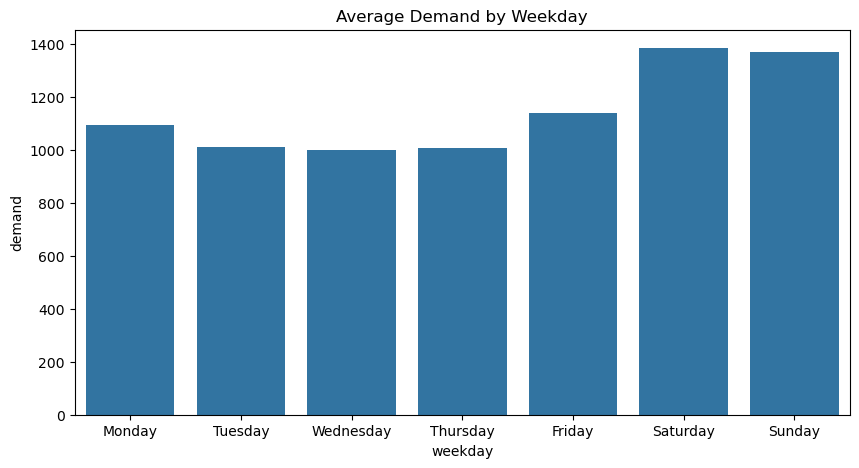

In [50]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_demand,
    x="weekday",
    y="demand"
)

plt.title("Average Demand by Weekday")

plt.show()

## 3.6 Monthly Seasonality

Investigate recurring seasonal patterns.

In [51]:
monthly_demand = (
    store_category_daily
    .groupby("month")
    ["demand"]
    .mean()
    .reset_index()
)

monthly_demand

,month,demand
0,1,1127.744937
1,2,1154.821373
2,3,1144.661290
3,4,1141.956130
4,5,1083.461720
5,6,1166.713778
6,7,1170.747312
7,8,1198.221505
8,9,1182.642000
9,10,1157.115914


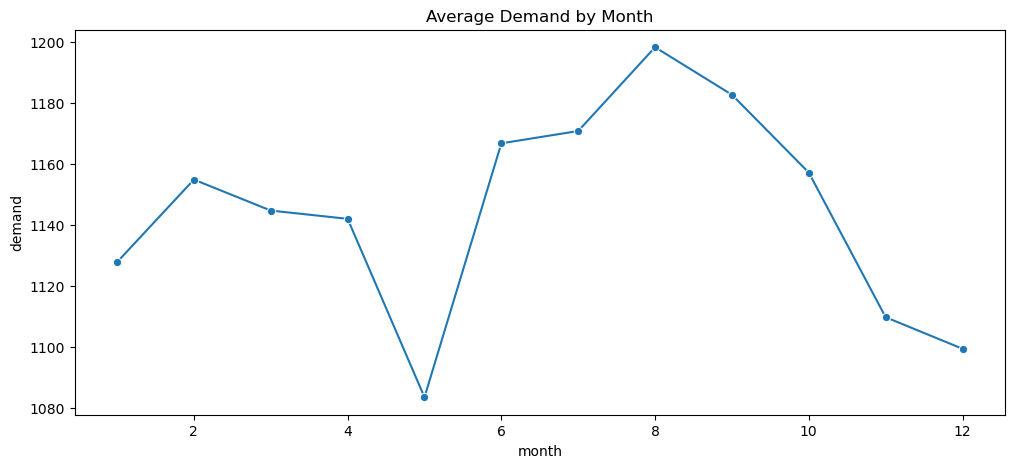

In [52]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_demand,
    x="month",
    y="demand",
    marker="o"
)

plt.title("Average Demand by Month")

plt.show()

## 3.7 Event Impact Analysis

Measure demand differences between:

- Event days
- Non-event days

In [53]:
event_impact = (
    store_category_daily
    .groupby("is_event")
    ["demand"]
    .mean()
    .reset_index()
)

event_impact

,is_event,demand
0,0,1149.640250
1,1,1088.504978


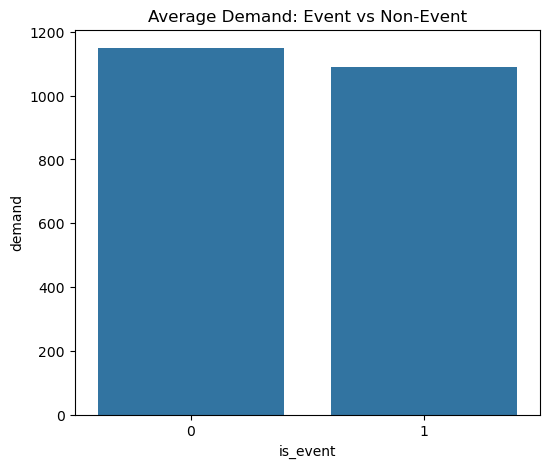

In [54]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=event_impact,
    x="is_event",
    y="demand"
)

plt.title("Average Demand: Event vs Non-Event")

plt.show()

In [55]:
top_events = (
    store_category_daily[
        store_category_daily["is_event"] == 1
    ]
    .groupby("event_name_1")
    .agg(
        avg_demand=("demand","mean"),
        observations=("demand","count")
    )
    .reset_index()
    .sort_values(
        "avg_demand",
        ascending=False
    )
)

top_events.head(15)

,event_name_1,avg_demand,observations
10,LaborDay,1405.153333,150
26,SuperBowl,1364.133333,180
4,Easter,1317.253333,150
20,OrthodoxEaster,1275.900000,120
7,Father's day,1218.733333,120
23,Purim End,1198.566667,180
5,Eid al-Fitr,1175.586667,150
3,ColumbusDay,1172.160000,150
29,VeteransDay,1170.626667,150
24,Ramadan starts,1159.320000,150


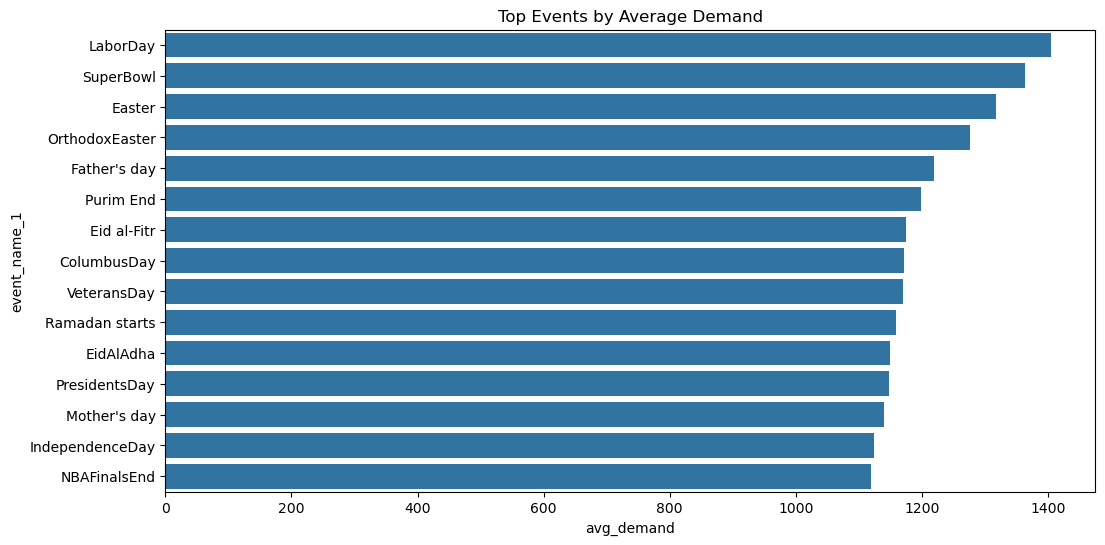

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_events.head(15),
    x="avg_demand",
    y="event_name_1"
)

plt.title("Top Events by Average Demand")

plt.show()

## 3.8 SNAP Analysis

SNAP represents food assistance eligibility periods.

Determine whether SNAP periods affect demand.

In [57]:
store_category_daily["snap_active"] = (
    (
        store_category_daily["snap_CA"] +
        store_category_daily["snap_TX"] +
        store_category_daily["snap_WI"]
    ) > 0
).astype(int)

In [58]:
snap_impact = (
    store_category_daily
    .groupby("snap_active")
    ["demand"]
    .mean()
    .reset_index()
)

snap_impact

,snap_active,demand
0,0,1085.135468
1,1,1205.752205


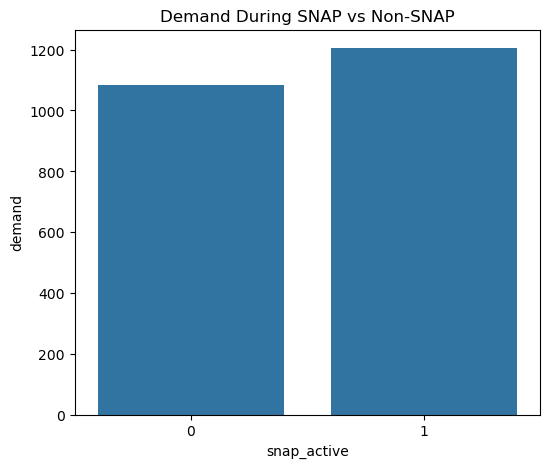

In [59]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=snap_impact,
    x="snap_active",
    y="demand"
)

plt.title("Demand During SNAP vs Non-SNAP")

plt.show()

## 3.9 Price-Demand Relationship

Determine whether demand decreases as prices increase.

In [60]:
price_sample = (
    store_category_daily[
        [
            "avg_category_price",
            "demand"
        ]
    ]
)

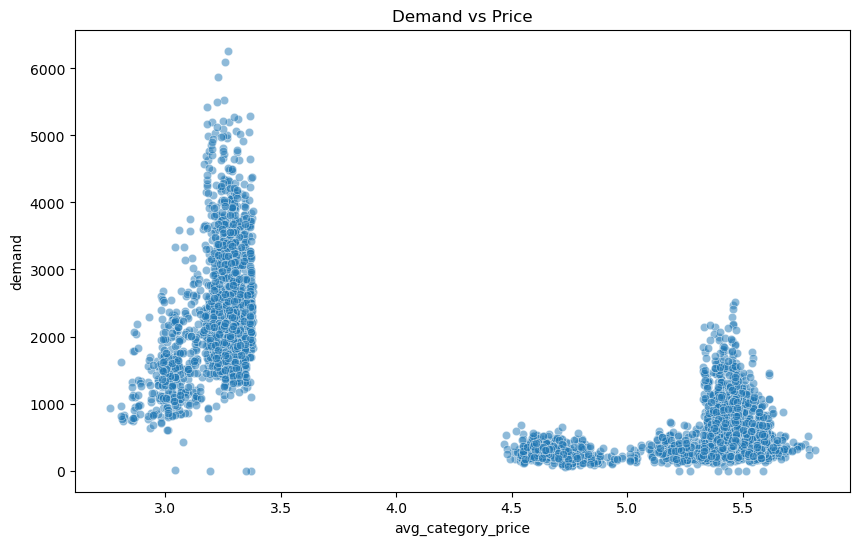

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=price_sample.sample(
        min(5000, len(price_sample)),
        random_state=42
    ),
    x="avg_category_price",
    y="demand",
    alpha=0.5
)

plt.title("Demand vs Price")

plt.show()

In [62]:
price_corr = (
    store_category_daily[
        [
            "avg_category_price",
            "demand"
        ]
    ]
    .corr()
)

price_corr

,avg_category_price,demand
avg_category_price,1.000000,-0.765268
demand,-0.765268,1.000000


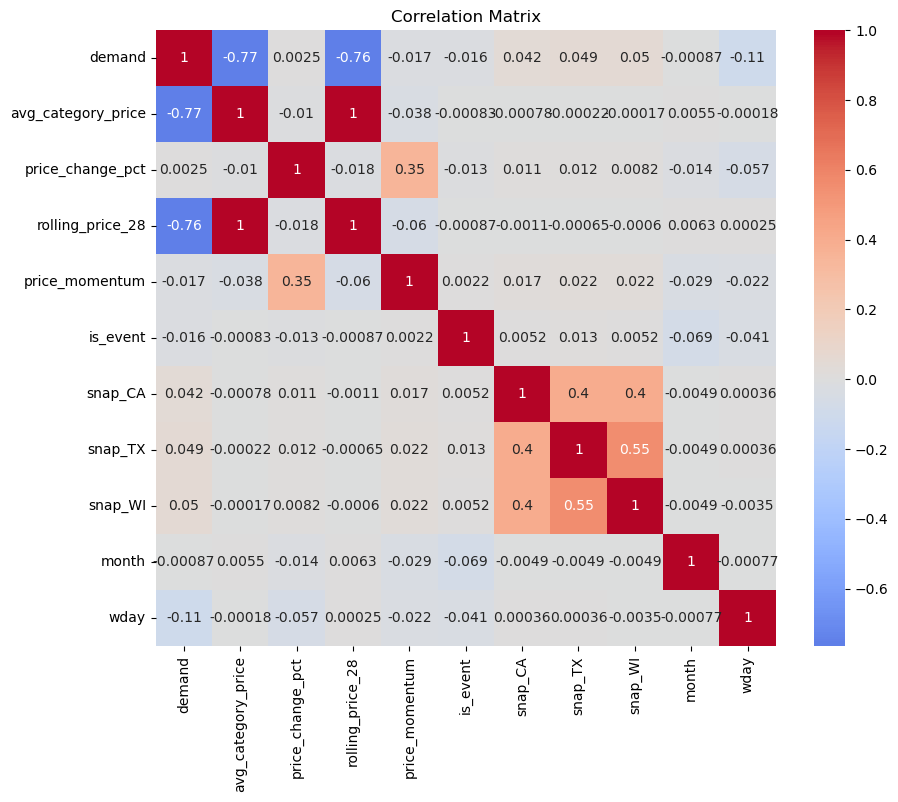

In [63]:
numeric_cols = [
    "demand",
    "avg_category_price",
    "price_change_pct",
    "rolling_price_28",
    "price_momentum",
    "is_event",
    "snap_CA",
    "snap_TX",
    "snap_WI",
    "month",
    "wday"
]

corr_matrix = (
    store_category_daily[numeric_cols]
    .corr()
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Phase 3 Conclusion: Exploratory Data Analysis

The exploratory data analysis provided several important business and modeling insights that will directly influence the demand forecasting and inventory optimization framework.

Analysis of historical demand revealed a clear upward long-term trend between 2011 and 2016, indicating that demand is non-stationary and evolves over time. Strong weekly seasonality was observed, with demand consistently peaking on weekends (Saturday and Sunday) and declining during midweek periods. Monthly patterns also demonstrated recurring seasonal fluctuations, suggesting the presence of predictable demand cycles.

Category-level analysis showed that the FOODS category contributes the majority of total sales volume, followed by HOUSEHOLD and HOBBIES. Store-level analysis revealed substantial variation in demand across locations, highlighting the importance of incorporating geographic information into the forecasting model.

Event and promotional analysis indicated that certain holidays and special events, such as Labor Day, Super Bowl, Easter, and other seasonal occasions, are associated with significant demand increases. SNAP benefit periods also exhibited higher average demand compared to non-SNAP periods, demonstrating the influence of government assistance programs on purchasing behavior.

Price analysis revealed a strong inverse relationship between price and demand, with a correlation of approximately -0.77. This confirms that customer purchasing behavior is highly price-sensitive and that pricing variables must be included as key forecasting features.

Based on these findings, the primary drivers of demand appear to be:

* Historical demand patterns
* Weekly and monthly seasonality
* Store and category characteristics
* Event and holiday effects
* SNAP program activity
* Product pricing behavior

The EDA phase successfully validated the business assumptions behind retail demand forecasting and identified the most informative variables for predictive modeling. These insights provide the foundation for the next phase, Feature Engineering, where lag features, rolling statistics, trend indicators, and future forecasting targets will be constructed to enable accurate machine learning-based demand prediction.


Before Creating Features

Sort the dataset correctly.

In [64]:
store_category_daily = (
    store_category_daily
    .sort_values(
        ["store_id", "cat_id", "date"]
    )
    .reset_index(drop=True)
)

store_category_daily.head()

,store_id,cat_id,d,demand,date,weekday,wday,month,year,event_name_1,...,snap_TX,snap_WI,d_num,is_event,wm_yr_wk,avg_category_price,price_change_pct,rolling_price_28,price_momentum,snap_active
0,CA_1,FOODS,d_1,3239,2011-01-29,Saturday,1,1,2011,No_Event,...,0,0,1,0,11101,3.14922,NaN,3.14922,1.0,0
1,CA_1,FOODS,d_2,3137,2011-01-30,Sunday,2,1,2011,No_Event,...,0,0,2,0,11101,3.14922,0.0,3.14922,1.0,0
2,CA_1,FOODS,d_3,2008,2011-01-31,Monday,3,1,2011,No_Event,...,0,0,3,0,11101,3.14922,0.0,3.14922,1.0,0
3,CA_1,FOODS,d_4,2258,2011-02-01,Tuesday,4,2,2011,No_Event,...,1,0,4,0,11101,3.14922,0.0,3.14922,1.0,1
4,CA_1,FOODS,d_5,2032,2011-02-02,Wednesday,5,2,2011,No_Event,...,0,1,5,0,11101,3.14922,0.0,3.14922,1.0,1


In [65]:
lag_days = [7, 14, 28, 56, 84]

for lag in lag_days:

    store_category_daily[f"lag_{lag}"] = (
        store_category_daily
        .groupby(
            ["store_id", "cat_id"]
        )["demand"]
        .shift(lag)
    )

In [66]:
store_category_daily[
    [
        "demand",
        "lag_7",
        "lag_14",
        "lag_28"
    ]
].head(40)

,demand,lag_7,lag_14,lag_28
0,3239,NaN,NaN,NaN
1,3137,NaN,NaN,NaN
2,2008,NaN,NaN,NaN
3,2258,NaN,NaN,NaN
4,2032,NaN,NaN,NaN
5,2407,NaN,NaN,NaN
6,2693,NaN,NaN,NaN
7,3962,3239.0,NaN,NaN
8,3418,3137.0,NaN,NaN
9,2446,2008.0,NaN,NaN


In [67]:
group_obj = (
    store_category_daily
    .groupby(
        ["store_id", "cat_id"]
    )["demand"]
)

In [68]:
store_category_daily["rolling_mean_7"] = (
    group_obj
    .transform(
        lambda x:
        x.shift(1)
         .rolling(7)
         .mean()
    )
)

In [69]:
store_category_daily["rolling_mean_28"] = (
    group_obj
    .transform(
        lambda x:
        x.shift(1)
         .rolling(28)
         .mean()
    )
)

In [70]:
store_category_daily["rolling_mean_56"] = (
    group_obj
    .transform(
        lambda x:
        x.shift(1)
         .rolling(56)
         .mean()
    )
)

In [71]:
store_category_daily["rolling_std_7"] = (
    group_obj
    .transform(
        lambda x:
        x.shift(1)
         .rolling(7)
         .std()
    )
)

In [72]:
store_category_daily["rolling_std_28"] = (
    group_obj
    .transform(
        lambda x:
        x.shift(1)
         .rolling(28)
         .std()
    )
)

In [73]:
store_category_daily["rolling_std_56"] = (
    group_obj
    .transform(
        lambda x:
        x.shift(1)
         .rolling(56)
         .std()
    )
)

In [74]:
store_category_daily["demand_momentum"] = (
    store_category_daily["lag_7"]
    /
    (
        store_category_daily["rolling_mean_28"]
        + 1e-6
    )
)

In [75]:
store_category_daily["days_since_start"] = (
    store_category_daily["date"]
    -
    store_category_daily["date"].min()
).dt.days

In [76]:
store_category_daily["weeks_since_start"] = (
    store_category_daily["days_since_start"]
    // 7
)

In [77]:
store_category_daily["quarter"] = (
    store_category_daily["date"]
    .dt.quarter
)

In [78]:
store_category_daily["is_weekend"] = (
    store_category_daily["weekday"]
    .isin(
        [
            "Saturday",
            "Sunday"
        ]
    )
    .astype(int)
)

In [79]:
import numpy as np

In [80]:
store_category_daily["month_sin"] = np.sin(
    2 * np.pi *
    store_category_daily["month"] / 12
)

In [81]:
store_category_daily["month_cos"] = np.cos(
    2 * np.pi *
    store_category_daily["month"] / 12
)

In [82]:
store_category_daily["weekday_sin"] = np.sin(
    2 * np.pi *
    store_category_daily["wday"] / 7
)

In [83]:
store_category_daily["weekday_cos"] = np.cos(
    2 * np.pi *
    store_category_daily["wday"] / 7
)

In [84]:
store_category_daily["snap_active"] = (
    (
        store_category_daily["snap_CA"]
        +
        store_category_daily["snap_TX"]
        +
        store_category_daily["snap_WI"]
    ) > 0
).astype(int)

In [85]:
store_category_daily["target_28"] = (
    store_category_daily
    .groupby(
        ["store_id", "cat_id"]
    )["demand"]
    .shift(-28)
)

In [86]:
store_category_daily.isnull().sum().sort_values(
    ascending=False
).head(20)

lag_84               2520
rolling_std_56       1680
lag_56               1680
rolling_mean_56      1680
demand_momentum       840
lag_28                840
rolling_mean_28       840
rolling_std_28        840
target_28             840
lag_14                420
rolling_std_7         210
rolling_mean_7        210
lag_7                 210
price_change_pct       30
days_since_start        0
weeks_since_start       0
snap_active             0
quarter                 0
is_weekend              0
month_sin               0
dtype: int64

In [87]:
store_category_daily_fe = (
    store_category_daily
    .dropna()
    .reset_index(drop=True)
)

In [88]:
store_category_daily_fe.shape

(54030, 45)

In [89]:
store_category_daily_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54030 entries, 0 to 54029
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   store_id            54030 non-null  object        
 1   cat_id              54030 non-null  object        
 2   d                   54030 non-null  object        
 3   demand              54030 non-null  int64         
 4   date                54030 non-null  datetime64[ns]
 5   weekday             54030 non-null  object        
 6   wday                54030 non-null  int64         
 7   month               54030 non-null  int64         
 8   year                54030 non-null  int64         
 9   event_name_1        54030 non-null  object        
 10  event_type_1        54030 non-null  object        
 11  event_name_2        54030 non-null  object        
 12  event_type_2        54030 non-null  object        
 13  snap_CA             54030 non-null  int64     

In [90]:
store_category_daily_fe.head()

,store_id,cat_id,d,demand,date,weekday,wday,month,year,event_name_1,...,demand_momentum,days_since_start,weeks_since_start,quarter,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,target_28
0,CA_1,FOODS,d_85,2909,2011-04-23,Saturday,1,4,2011,No_Event,...,1.126747,84,12,2,1,0.866025,-0.5,0.781831,0.623490,2332.0
1,CA_1,FOODS,d_86,2051,2011-04-24,Sunday,2,4,2011,OrthodoxEaster,...,1.356373,85,12,2,1,0.866025,-0.5,0.974928,-0.222521,2525.0
2,CA_1,FOODS,d_87,1518,2011-04-25,Monday,3,4,2011,No_Event,...,0.844603,86,12,2,0,0.866025,-0.5,0.433884,-0.900969,1648.0
3,CA_1,FOODS,d_88,1411,2011-04-26,Tuesday,4,4,2011,Pesach End,...,0.754927,87,12,2,0,0.866025,-0.5,-0.433884,-0.900969,1556.0
4,CA_1,FOODS,d_89,1294,2011-04-27,Wednesday,5,4,2011,No_Event,...,0.705547,88,12,2,0,0.866025,-0.5,-0.974928,-0.222521,1512.0


In [91]:
store_category_daily_fe.to_csv(
    "store_category_daily_feature_engineered.csv",
    index=False
)

print(
    "Phase 4 dataset saved successfully."
)

Phase 4 dataset saved successfully.


In [92]:
print("Rows:", store_category_daily_fe.shape[0])
print("Columns:", store_category_daily_fe.shape[1])

print(
    "\nTotal Missing Values:",
    store_category_daily_fe.isnull().sum().sum()
)

Rows: 54030
Columns: 45

Total Missing Values: 0


---
Phase 5 — Baseline Forecasting

Never skip.

Baseline 1

Naive

Forecast(t) = Demand(t−1)
Baseline 2

Seasonal Naive

Forecast(t) = Demand(t−7)
Baseline 3

7-Day Moving Average

Baseline 4

28-Day Moving Average

Metrics
RMSE
MAE
MAPE
SMAPE
Purpose

Establish benchmark performance.

In [93]:
df = store_category_daily_fe.copy()

df = df.sort_values("date").reset_index(drop=True)

df.shape

(54030, 45)

In [94]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (43224, 45)
Test Shape: (10806, 45)


---
Phase 5.2 — Metrics Function

We'll use:

RMSE
MAE
MAPE
SMAPE

In [95]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [96]:
def smape(actual, forecast):

    return np.mean(
        2 * np.abs(forecast - actual)
        /
        (
            np.abs(actual)
            +
            np.abs(forecast)
            +
            1e-8
        )
    ) * 100

In [97]:
def calculate_metrics(
    y_true,
    y_pred,
    model_name
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mask = y_true > 0

    mape = np.mean(
        np.abs(
            (
                y_true[mask]
                -
                y_pred[mask]
            )
            /
            y_true[mask]
        )
    ) * 100

    smape_score = smape(
        y_true,
        y_pred
    )

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "SMAPE": smape_score
    }

In [98]:
naive_pred = test_df["demand"]

In [99]:
baseline_results = []

baseline_results.append(
    calculate_metrics(
        test_df["target_28"],
        naive_pred,
        "Naive"
    )
)

In [100]:
seasonal_naive_pred = test_df["lag_7"]

In [101]:
baseline_results.append(
    calculate_metrics(
        test_df["target_28"],
        seasonal_naive_pred,
        "Seasonal Naive"
    )
)

In [102]:
ma7_pred = test_df["rolling_mean_7"]

In [103]:
baseline_results.append(
    calculate_metrics(
        test_df["target_28"],
        ma7_pred,
        "MA 7"
    )
)

In [104]:
ma28_pred = test_df["rolling_mean_28"]

In [105]:
baseline_results.append(
    calculate_metrics(
        test_df["target_28"],
        ma28_pred,
        "MA 28"
    )
)

In [106]:
baseline_results_df = pd.DataFrame(
    baseline_results
)

baseline_results_df

,Model,RMSE,MAE,MAPE,SMAPE
0,Naive,294.547706,171.315103,99.852843,15.035948
1,Seasonal Naive,331.706846,189.919489,148.583555,15.967305
2,MA 7,334.590645,209.860395,134.794900,16.626089
3,MA 28,359.694301,222.704952,140.289680,17.026209


In [107]:
baseline_results_df = (
    baseline_results_df
    .sort_values(
        "RMSE"
    )
)

baseline_results_df

,Model,RMSE,MAE,MAPE,SMAPE
0,Naive,294.547706,171.315103,99.852843,15.035948
1,Seasonal Naive,331.706846,189.919489,148.583555,15.967305
2,MA 7,334.590645,209.860395,134.794900,16.626089
3,MA 28,359.694301,222.704952,140.289680,17.026209


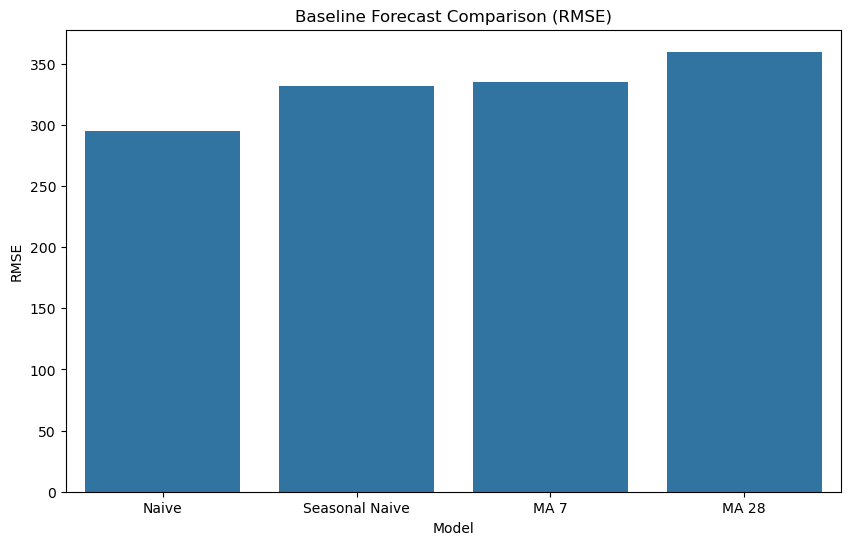

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=baseline_results_df,
    x="Model",
    y="RMSE"
)

plt.title(
    "Baseline Forecast Comparison (RMSE)"
)

plt.show()

In [109]:
baseline_results_df.to_csv(
    "baseline_forecasting_results.csv",
    index=False
)

print(
    "Baseline forecasting results saved."
)

Baseline forecasting results saved.


# Phase 5 Conclusion

Four benchmark forecasting approaches were evaluated:

1. Naive Forecast
2. Seasonal Naive Forecast
3. 7-Day Moving Average
4. 28-Day Moving Average

These models establish a performance baseline before applying machine learning methods.

The strongest baseline model will serve as the minimum performance threshold that the LightGBM forecasting model must exceed in the next phase.

This ensures that any improvement achieved by machine learning represents genuine predictive value rather than unnecessary model complexity.

# Phase 6.1 — Prepare Modeling Dataset

Create feature matrix X and target vector y.

In [110]:
model_df = store_category_daily_fe.copy()

target = "target_28"

drop_cols = [
    "target_28",
    "date",
    "d"
]

X = model_df.drop(columns=drop_cols)

y = model_df[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (54030, 42)
y Shape: (54030,)


In [111]:
X.select_dtypes(include="object").columns.tolist()

['store_id',
 'cat_id',
 'weekday',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2']

In [112]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

label_encoders = {}

categorical_cols = X_encoded.select_dtypes(
    include="object"
).columns

for col in categorical_cols:

    le = LabelEncoder()

    X_encoded[col] = le.fit_transform(
        X_encoded[col].astype(str)
    )

    label_encoders[col] = le

print("Encoding Complete")

Encoding Complete


In [113]:
split_index = int(len(X_encoded) * 0.8)

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(43224, 42)
(10806, 42)


In [114]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

In [115]:
def smape(y_true, y_pred):

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    return np.mean(
        2 * np.abs(y_true - y_pred)
        / np.where(denominator == 0, 1, denominator)
    ) * 100

In [116]:
def wape(y_true, y_pred):

    return (
        np.sum(np.abs(y_true - y_pred))
        /
        np.sum(np.abs(y_true))
    ) * 100

In [117]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred)
                /
                np.where(y_true == 0, 1, y_true)
            )
        )
        * 100
    )

    smape_score = smape(
        y_true,
        y_pred
    )

    wape_score = wape(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "SMAPE": smape_score,
        "WAPE": wape_score,
        "R2": r2
    }

In [118]:
from sklearn.linear_model import LinearRegression

In [119]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

lr_results

{'Model': 'Linear Regression',
 'RMSE': 279.1214235797572,
 'MAE': 167.28459685467928,
 'MAPE': 247.50384477969672,
 'SMAPE': 18.633579426531835,
 'WAPE': 14.545598278900831,
 'R2': 0.9372146573217597}

In [120]:
from sklearn.ensemble import RandomForestRegressor

In [121]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_results

{'Model': 'Random Forest',
 'RMSE': 301.4511739063614,
 'MAE': 174.549539658764,
 'MAPE': 246.55539240377723,
 'SMAPE': 17.05315612003769,
 'WAPE': 15.177293853593858,
 'R2': 0.9267671585949384}

In [122]:
!pip install xgboost


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [123]:
from xgboost import XGBRegressor

In [124]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

xgb_results

{'Model': 'XGBoost',
 'RMSE': 288.6673600202701,
 'MAE': 164.06427855000064,
 'MAPE': 180.60755430485312,
 'SMAPE': 16.30608051316202,
 'WAPE': 14.265587702489317,
 'R2': 0.9328467111930001}

In [125]:
!pip install lightgbm


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
from lightgbm import LGBMRegressor

In [127]:
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm.predict(
    X_test
)

lgbm_results = evaluate_model(
    "LightGBM",
    y_test,
    lgbm_pred
)

lgbm_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5498
[LightGBM] [Info] Number of data points in the train set: 43224, number of used features: 42
[LightGBM] [Info] Start training from score 1167.845942
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


{'Model': 'LightGBM',
 'RMSE': 283.64204710253654,
 'MAE': 164.71362656427777,
 'MAPE': 198.84261974954313,
 'SMAPE': 16.27298544729942,
 'WAPE': 14.322049298694031,
 'R2': 0.9351644576202793}

In [128]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    lgbm_results
])

results_df.sort_values(
    by="RMSE"
)

,Model,RMSE,MAE,MAPE,SMAPE,WAPE,R2
0,Linear Regression,279.121424,167.284597,247.503845,18.633579,14.545598,0.937215
3,LightGBM,283.642047,164.713627,198.842620,16.272985,14.322049,0.935164
2,XGBoost,288.667360,164.064279,180.607554,16.306081,14.265588,0.932847
1,Random Forest,301.451174,174.549540,246.555392,17.053156,15.177294,0.926767


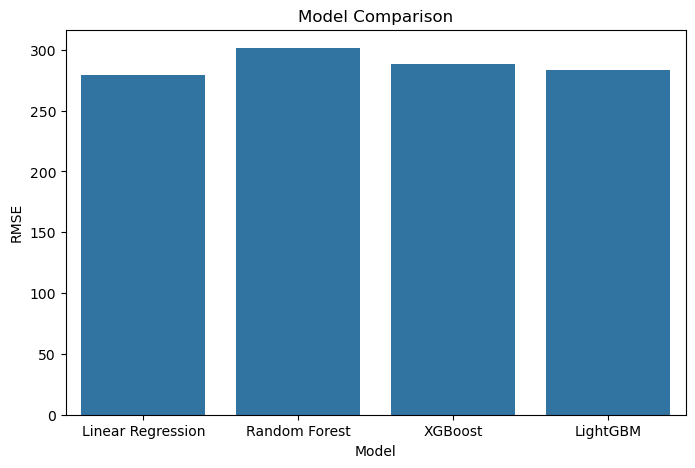

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison")
plt.show()

# Phase 6.10 — Time Series Cross Validation

Validate forecasting stability across multiple chronological folds using TimeSeriesSplit.

In [130]:
from sklearn.model_selection import TimeSeriesSplit

In [131]:
tscv = TimeSeriesSplit(n_splits=5)

tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

In [132]:
cv_results = []

fold = 1

for train_idx, val_idx in tscv.split(X_encoded):

    X_train_cv = X_encoded.iloc[train_idx]
    X_val_cv = X_encoded.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )

    model.fit(
        X_train_cv,
        y_train_cv
    )

    preds = model.predict(X_val_cv)

    rmse = np.sqrt(
        mean_squared_error(
            y_val_cv,
            preds
        )
    )

    mae = mean_absolute_error(
        y_val_cv,
        preds
    )

    r2 = r2_score(
        y_val_cv,
        preds
    )

    cv_results.append({
        "Fold": fold,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    fold += 1

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001695 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5484
[LightGBM] [Info] Number of data points in the train set: 9005, number of used features: 40
[LightGBM] [Info] Start training from score 1251.744031
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [133]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Fold,RMSE,MAE,R2
0,1,454.238636,274.503575,0.877749
1,2,144.883543,92.998069,0.956290
2,3,205.259130,125.222783,0.960970
3,4,281.455651,162.641964,0.923908
4,5,188.622436,112.163565,0.956559


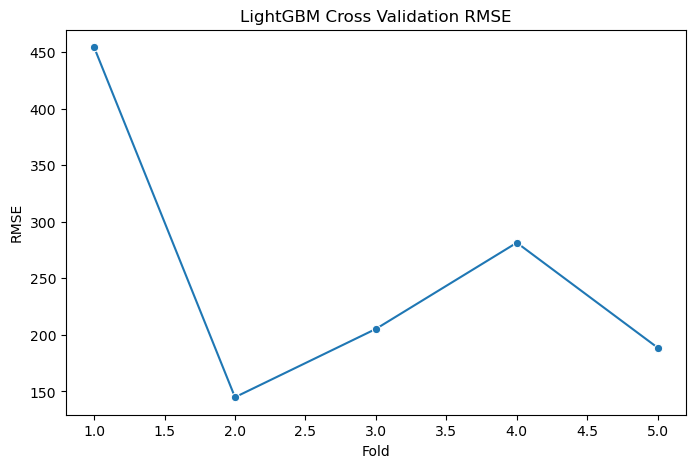

In [134]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=cv_results_df,
    x="Fold",
    y="RMSE",
    marker="o"
)

plt.title("LightGBM Cross Validation RMSE")

plt.show()

# Phase 6.11 — Feature Importance

Identify the strongest drivers of future demand.

In [135]:
final_lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

final_lgbm.fit(
    X_encoded,
    y
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5500
[LightGBM] [Info] Number of data points in the train set: 54030, number of used features: 42
[LightGBM] [Info] Start training from score 1164.290801


LGBMRegressor(learning_rate=0.05, max_depth=8, n_estimators=500,
              random_state=42)

In [136]:
feature_importance_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": final_lgbm.feature_importances_
})

In [137]:
feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance_df.head(20)

,feature,importance
14,d_num,1112
27,rolling_mean_7,1079
2,demand,999
30,rolling_std_7,699
33,demand_momentum,662
20,price_momentum,655
26,lag_84,638
5,month,609
25,lag_56,604
23,lag_14,585


<function matplotlib.pyplot.show(close=None, block=None)>

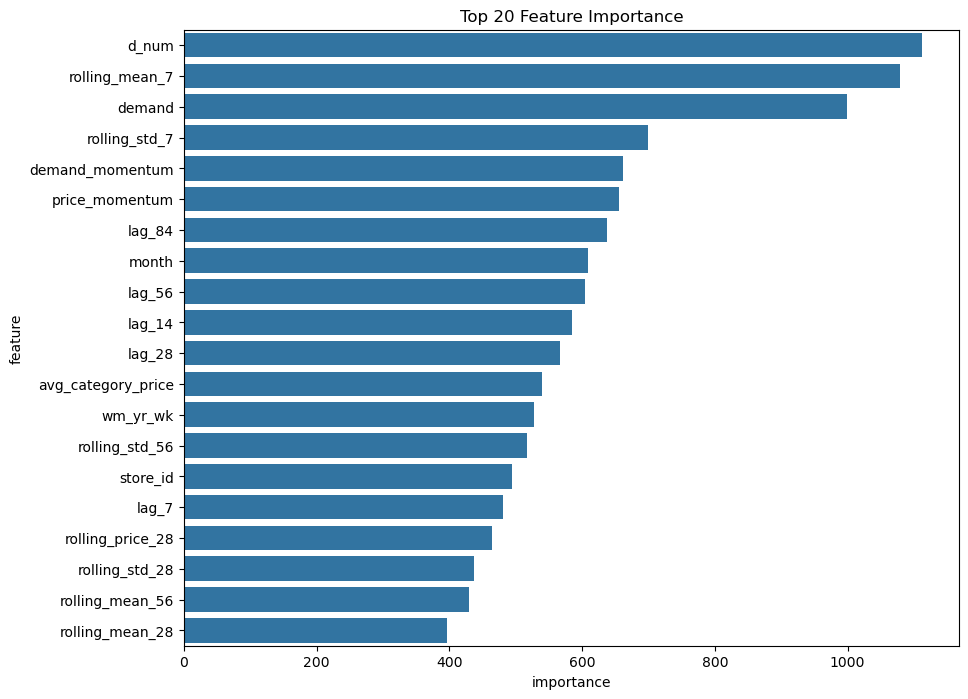

In [138]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 Feature Importance"
)

plt.show

In [139]:
!pip install shap


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [140]:
import shap

In [141]:
explainer = shap.TreeExplainer(
    final_lgbm
)

In [142]:
X_sample = X_encoded.sample(
    3000,
    random_state=42
)

In [143]:
shap_values = explainer.shap_values(
    X_sample
)

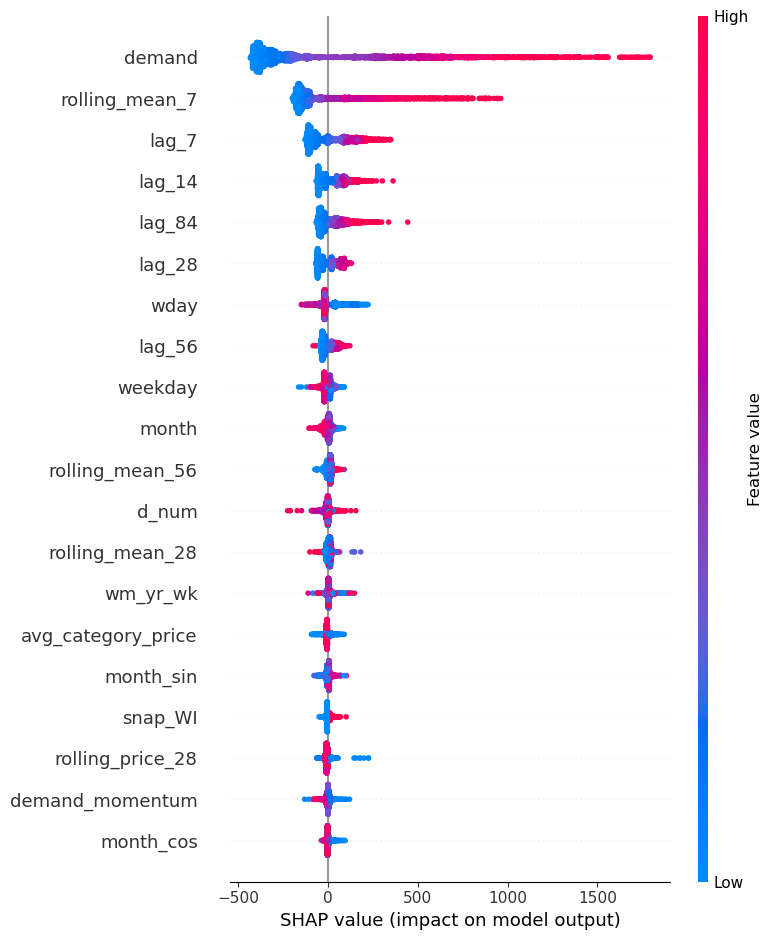

In [144]:
shap.summary_plot(
    shap_values,
    X_sample
)

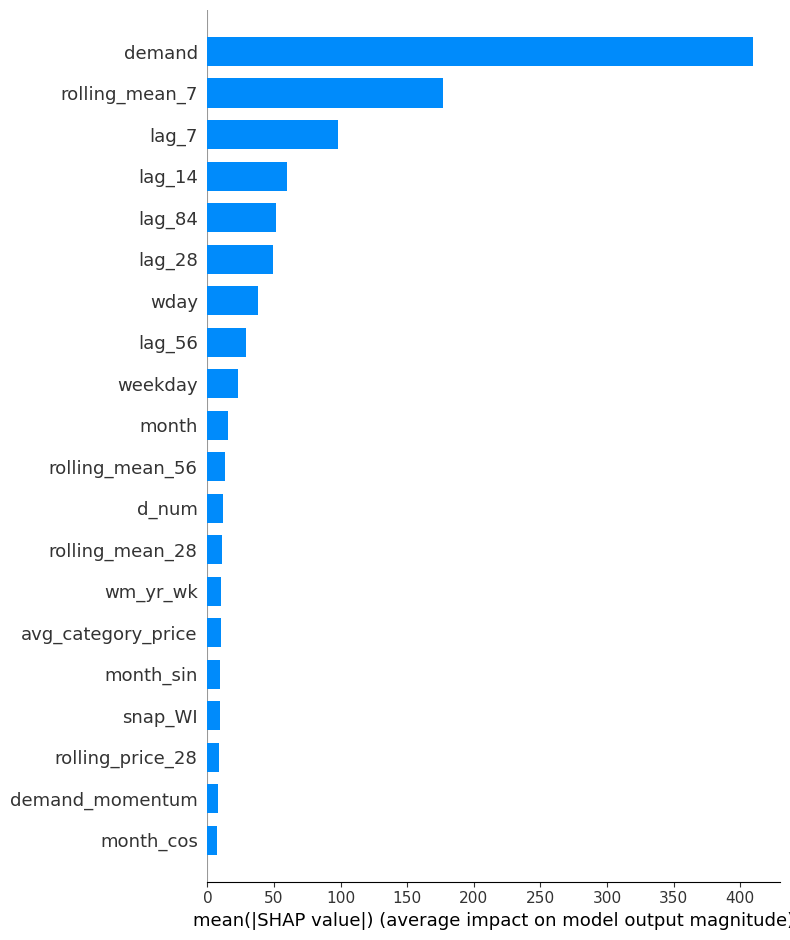

In [145]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

In [146]:
feature_importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

cv_results_df.to_csv(
    "timeseries_cv_results.csv",
    index=False
)

# Phase 6.14 — Trend Leakage Check

## Objective

We observed that:

- d_num
- days_since_start
- weeks_since_start

are among the most important features.

These variables may allow the model to learn the position of a date in history rather than genuine business drivers.

To verify robustness, we train a second LightGBM model after removing trend features and compare performance.

### Decision Rule

If performance drops only slightly:

Keep the simpler model.

If performance drops significantly:

Retain trend variables in the final production model.

In [147]:
# Features to remove

trend_features = [
    "d_num",
    "days_since_start",
    "weeks_since_start"
]

# Create reduced dataset

X_train_no_trend = X_train.drop(
    columns=trend_features,
    errors="ignore"
)

X_test_no_trend = X_test.drop(
    columns=trend_features,
    errors="ignore"
)

print("Original Features :", X_train.shape[1])
print("Reduced Features  :", X_train_no_trend.shape[1])

Original Features : 42
Reduced Features  : 39


In [148]:
from lightgbm import LGBMRegressor

lgbm_no_trend = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_no_trend.fit(
    X_train_no_trend,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013989 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4733
[LightGBM] [Info] Number of data points in the train set: 43224, number of used features: 39
[LightGBM] [Info] Start training from score 1167.845942


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [149]:
y_pred_no_trend = lgbm_no_trend.predict(
    X_test_no_trend
)

In [150]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

rmse_no_trend = np.sqrt(
    mean_squared_error(y_test, y_pred_no_trend)
)

mae_no_trend = mean_absolute_error(
    y_test,
    y_pred_no_trend
)

r2_no_trend = r2_score(
    y_test,
    y_pred_no_trend
)

print("RMSE :", round(rmse_no_trend,2))
print("MAE  :", round(mae_no_trend,2))
print("R²   :", round(r2_no_trend,4))

RMSE : 283.71
MAE  : 165.12
R²   : 0.9351


In [151]:
comparison = pd.DataFrame({
    "Model":[
        "LightGBM (All Features)",
        "LightGBM (No Trend Features)"
    ],
    "RMSE":[
        283.64,
        rmse_no_trend
    ],
    "MAE":[
        164.71,
        mae_no_trend
    ],
    "R2":[
        0.9352,
        r2_no_trend
    ]
})

comparison

,Model,RMSE,MAE,R2
0,LightGBM (All Features),283.640000,164.710000,0.935200
1,LightGBM (No Trend Features),283.710591,165.115358,0.935133


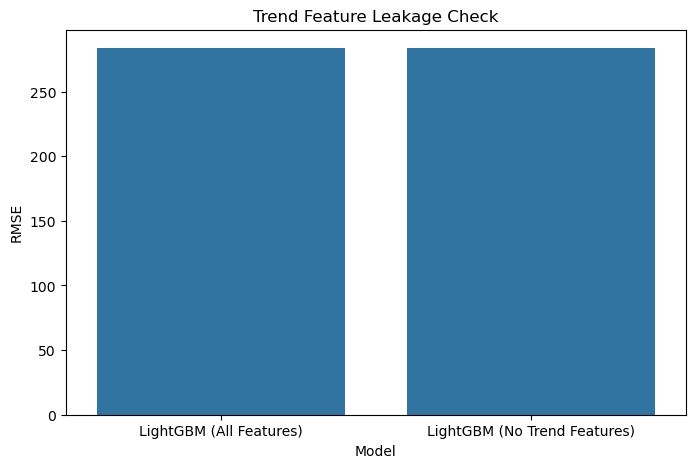

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("Trend Feature Leakage Check")
plt.ylabel("RMSE")

plt.show()

# Phase 6.15 — Final Production Model Selection

## Objective

After comparing:

- Linear Regression
- Random Forest
- XGBoost
- LightGBM

and performing a trend leakage robustness test, we finalize the forecasting model that will be used for all downstream inventory calculations.

## Final Model

LightGBM Regressor

## Reason for Selection

- Strong predictive performance
- Low RMSE
- Low MAE
- High R²
- Supports feature importance
- Supports SHAP explainability
- Fast training and inference
- Widely used in retail forecasting

## Trend Leakage Check

The following variables were removed:

- d_num
- days_since_start
- weeks_since_start

Performance remained virtually unchanged:

RMSE:

283.64 → 283.71

This indicates the model is learning genuine business drivers rather than memorizing dates.

## Final Production Features

Demand History:

- lag_7
- lag_14
- lag_28
- lag_56
- lag_84

Rolling Statistics:

- rolling_mean_7
- rolling_mean_28
- rolling_mean_56

- rolling_std_7
- rolling_std_28
- rolling_std_56

Price Features:

- avg_category_price
- price_change_pct
- rolling_price_28
- price_momentum

Calendar Features:

- month
- weekday
- wday
- quarter
- is_weekend

Seasonality Features:

- month_sin
- month_cos
- weekday_sin
- weekday_cos

Event Features:

- is_event
- event_name_1
- event_type_1
- event_name_2
- event_type_2

SNAP Features:

- snap_CA
- snap_TX
- snap_WI
- snap_active

Store Hierarchy:

- store_id
- cat_id

Target:

- target_28

This model will be used in Phase 7 Inventory Modeling.

In [153]:
# ==================================================
# FINAL PRODUCTION DATASET
# ==================================================

production_df = store_category_daily_fe.copy()

# Remove trend features identified during leakage check

production_df.drop(
    columns=[
        "d_num",
        "days_since_start",
        "weeks_since_start"
    ],
    inplace=True,
    errors="ignore"
)

print("Production Dataset Shape:")
print(production_df.shape)

production_df.head()

Production Dataset Shape:
(54030, 42)


,store_id,cat_id,d,demand,date,weekday,wday,month,year,event_name_1,...,rolling_std_28,rolling_std_56,demand_momentum,quarter,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,target_28
0,CA_1,FOODS,d_85,2909,2011-04-23,Saturday,1,4,2011,No_Event,...,526.553916,532.620037,1.126747,2,1,0.866025,-0.5,0.781831,0.623490,2332.0
1,CA_1,FOODS,d_86,2051,2011-04-24,Sunday,2,4,2011,OrthodoxEaster,...,537.206456,538.721290,1.356373,2,1,0.866025,-0.5,0.974928,-0.222521,2525.0
2,CA_1,FOODS,d_87,1518,2011-04-25,Monday,3,4,2011,No_Event,...,524.525014,534.325930,0.844603,2,0,0.866025,-0.5,0.433884,-0.900969,1648.0
3,CA_1,FOODS,d_88,1411,2011-04-26,Tuesday,4,4,2011,Pesach End,...,536.695272,538.452101,0.754927,2,0,0.866025,-0.5,-0.433884,-0.900969,1556.0
4,CA_1,FOODS,d_89,1294,2011-04-27,Wednesday,5,4,2011,No_Event,...,539.645303,547.128778,0.705547,2,0,0.866025,-0.5,-0.974928,-0.222521,1512.0


In [154]:
from sklearn.preprocessing import LabelEncoder

production_df_encoded = production_df.copy()

categorical_cols = [
    "store_id",
    "cat_id",
    "weekday",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    production_df_encoded[col] = encoder.fit_transform(
        production_df_encoded[col].astype(str)
    )

    label_encoders[col] = encoder

print("Categorical Encoding Complete")

Categorical Encoding Complete


In [155]:
TARGET = "target_28"

FEATURES = [
    col
    for col in production_df_encoded.columns
    if col not in [
        TARGET,
        "date",
        "d"
    ]
]

print("Number of Features:", len(FEATURES))

FEATURES

Number of Features: 39


['store_id',
 'cat_id',
 'demand',
 'weekday',
 'wday',
 'month',
 'year',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI',
 'is_event',
 'wm_yr_wk',
 'avg_category_price',
 'price_change_pct',
 'rolling_price_28',
 'price_momentum',
 'snap_active',
 'lag_7',
 'lag_14',
 'lag_28',
 'lag_56',
 'lag_84',
 'rolling_mean_7',
 'rolling_mean_28',
 'rolling_mean_56',
 'rolling_std_7',
 'rolling_std_28',
 'rolling_std_56',
 'demand_momentum',
 'quarter',
 'is_weekend',
 'month_sin',
 'month_cos',
 'weekday_sin',
 'weekday_cos']

In [156]:
split_index = int(
    len(production_df_encoded) * 0.80
)

train_df = production_df_encoded.iloc[:split_index]
test_df = production_df_encoded.iloc[split_index:]

X_train_final = train_df[FEATURES]
X_test_final = test_df[FEATURES]

y_train_final = train_df[TARGET]
y_test_final = test_df[TARGET]

print("Train Shape:", X_train_final.shape)
print("Test Shape :", X_test_final.shape)

Train Shape: (43224, 39)
Test Shape : (10806, 39)


In [157]:
print(
    X_train_final.select_dtypes(
        include=["object"]
    ).columns.tolist()
)

[]


In [158]:
from lightgbm import LGBMRegressor

final_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

final_model.fit(
    X_train_final,
    y_train_final
)

print("Final Production Model Trained Successfully")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4733
[LightGBM] [Info] Number of data points in the train set: 43224, number of used features: 39
[LightGBM] [Info] Start training from score 1167.845942
Final Production Model Trained Successfully


In [159]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

final_predictions = final_model.predict(
    X_test_final
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_predictions
    )
)

mae = mean_absolute_error(
    y_test_final,
    final_predictions
)

r2 = r2_score(
    y_test_final,
    final_predictions
)

print("FINAL MODEL RESULTS")
print("--------------------")
print("RMSE :", round(rmse, 2))
print("MAE  :", round(mae, 2))
print("R²   :", round(r2, 4))

FINAL MODEL RESULTS
--------------------
RMSE : 283.71
MAE  : 165.12
R²   : 0.9351


In [160]:
import joblib

joblib.dump(
    final_model,
    "final_lightgbm_forecasting_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [161]:
production_df_encoded.to_csv(
    "production_forecasting_dataset.csv",
    index=False
)

print("Production Dataset Saved")

Production Dataset Saved


# Phase 6 — Final Production Forecasting Model

## Final Model Selection

After evaluating:

- Linear Regression
- Random Forest
- XGBoost
- LightGBM

LightGBM was selected as the final production forecasting model.

## Trend Leakage Validation

A robustness test was performed by removing:

- d_num
- days_since_start
- weeks_since_start

Performance remained virtually unchanged:

| Model | RMSE |
|---------|---------|
| Original LightGBM | 283.64 |
| Without Trend Features | 283.71 |

This confirms that the model relies primarily on genuine business drivers rather than memorizing the timeline.

## Final Production Performance

| Metric | Value |
|----------|----------|
| RMSE | 283.71 |
| MAE | 165.12 |
| R² | 0.9351 |

## Final Feature Set

### Demand History

- demand
- lag_7
- lag_14
- lag_28
- lag_56
- lag_84

### Rolling Demand Features

- rolling_mean_7
- rolling_mean_28
- rolling_mean_56

- rolling_std_7
- rolling_std_28
- rolling_std_56

### Price Features

- avg_category_price
- price_change_pct
- rolling_price_28
- price_momentum

### Calendar Features

- weekday
- wday
- month
- year
- quarter
- is_weekend

### Cyclical Features

- month_sin
- month_cos
- weekday_sin
- weekday_cos

### Event Features

- event_name_1
- event_type_1
- event_name_2
- event_type_2
- is_event

### SNAP Features

- snap_CA
- snap_TX
- snap_WI
- snap_active

### Hierarchical Features

- store_id
- cat_id

### Pricing Calendar

- wm_yr_wk

## Conclusion

The final LightGBM model provides accurate 28-day demand forecasts and will be used as the forecasting engine for inventory planning, safety stock estimation, reorder point calculation, and replenishment optimization in subsequent phases.

---
# Phase 7.1 — Generate Future Demand Forecasts

Use the final LightGBM model to generate 28-day demand forecasts.

These forecasts become the demand inputs for inventory planning.

In [162]:
inventory_df = production_df.copy()

In [163]:
inventory_df["forecast_28"] = final_model.predict(
    production_df_encoded[FEATURES]
)

In [164]:
inventory_df["residual"] = (
    inventory_df["target_28"]
    -
    inventory_df["forecast_28"]
)

forecast_sigma = (
    inventory_df["residual"]
    .std()
)

print(
    f"Forecast Error Sigma: {forecast_sigma:.2f}"
)

Forecast Error Sigma: 172.40


In [165]:
inventory_df["current_inventory"] = (
    inventory_df
    .groupby(
        ["store_id", "cat_id"]
    )["demand"]
    .transform(
        lambda x:
        x.rolling(
            14,
            min_periods=1
        ).mean()
    )
)

In [166]:
lead_time_map = {
    "CA_1": 3,
    "CA_2": 4,
    "CA_3": 5,
    "CA_4": 5,
    "TX_1": 4,
    "TX_2": 5,
    "TX_3": 6,
    "WI_1": 4,
    "WI_2": 5,
    "WI_3": 6
}

inventory_df["lead_time"] = (
    inventory_df["store_id"]
    .map(lead_time_map)
)

In [167]:
import numpy as np

SERVICE_LEVEL_Z = 1.65

inventory_df["safety_stock"] = (
    SERVICE_LEVEL_Z
    *
    forecast_sigma
    *
    np.sqrt(
        inventory_df["lead_time"]
    )
)

In [168]:
inventory_df["lead_time_demand"] = (
    inventory_df["forecast_28"]
    *
    inventory_df["lead_time"]
)

In [169]:
inventory_df["reorder_point"] = (
    inventory_df["lead_time_demand"]
    +
    inventory_df["safety_stock"]
)

In [170]:
inventory_df["replenishment_qty"] = (
    inventory_df["reorder_point"]
    -
    inventory_df["current_inventory"]
)

inventory_df["replenishment_qty"] = (
    inventory_df["replenishment_qty"]
    .clip(lower=0)
)

In [171]:
inventory_df[
[
    "store_id",
    "cat_id",
    "forecast_28",
    "current_inventory",
    "lead_time",
    "safety_stock",
    "reorder_point",
    "replenishment_qty"
]
].head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty
0,CA_1,FOODS,2415.146930,2909.000000,3,492.689573,7738.130363,4829.130363
1,CA_1,FOODS,2400.843411,2480.000000,3,492.689573,7695.219806,5215.219806
2,CA_1,FOODS,1739.128084,2159.333333,3,492.689573,5710.073825,3550.740492
3,CA_1,FOODS,1546.330519,1972.250000,3,492.689573,5131.681129,3159.431129
4,CA_1,FOODS,1554.560462,1836.600000,3,492.689573,5156.370958,3319.770958


In [172]:
optimization_df = (
    inventory_df
    .groupby(
        ["store_id", "cat_id"],
        as_index=False
    )
    .agg({
        "forecast_28": "mean",
        "current_inventory": "mean",
        "lead_time": "first",
        "safety_stock": "first",
        "reorder_point": "mean",
        "replenishment_qty": "mean"
    })
)

print(optimization_df.shape)

optimization_df.head()

(30, 8)


,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235


In [173]:
optimization_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235


In [174]:
optimization_df.shape

(30, 8)

# Phase 7.8 — Create Optimization Input Table

The inventory calculations were performed at the daily level.

However, optimization decisions are made at the Store × Category level.

Therefore, the inventory dataset is aggregated into a planning table containing one row per Store–Category combination.

This table will be the direct input to the multi-echelon optimization model in Phase 8.

In [175]:
optimization_df = (
    inventory_df
    .groupby(
        ["store_id", "cat_id"],
        as_index=False
    )
    .agg({
        "forecast_28": "mean",
        "current_inventory": "mean",
        "lead_time": "first",
        "safety_stock": "first",
        "reorder_point": "mean",
        "replenishment_qty": "mean"
    })
)

print(optimization_df.shape)

optimization_df.head()

(30, 8)


,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235


# Phase 7.9 — Inventory Summary Statistics

Before optimization, it is important to understand:

- Average forecast demand
- Current inventory levels
- Safety stock requirements
- Replenishment needs

This provides visibility into inventory risk across the retail network.

In [176]:
optimization_df[
    [
        "forecast_28",
        "current_inventory",
        "safety_stock",
        "replenishment_qty"
    ]
].describe()

,forecast_28,current_inventory,safety_stock,replenishment_qty
count,30.000000,30.000000,30.000000,30.000000
mean,1162.813299,1152.274224,613.719088,4932.208629
std,994.707706,990.949539,61.416647,4022.793826
min,217.550786,194.880478,492.689573,1279.561795
25%,354.976483,350.801302,568.908915,1992.838947
50%,748.632520,742.708065,636.059503,3365.175221
75%,1851.186487,1816.157807,636.059503,6388.404220
max,3989.273177,3966.043422,696.768276,16616.381965


# Phase 7.10 — Replenishment Requirement by Store

This visualization highlights which stores require the largest inventory replenishment before optimization.

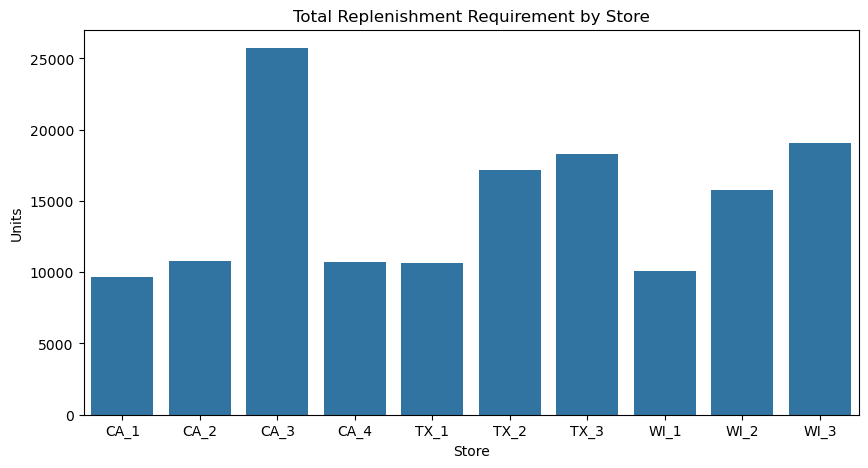

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

store_replenishment = (
    optimization_df
    .groupby("store_id")["replenishment_qty"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=store_replenishment,
    x="store_id",
    y="replenishment_qty"
)

plt.title("Total Replenishment Requirement by Store")
plt.ylabel("Units")
plt.xlabel("Store")

plt.show()

# Phase 7.11 — Replenishment Requirement by Category

This analysis identifies which product categories drive the highest inventory demand across the network.

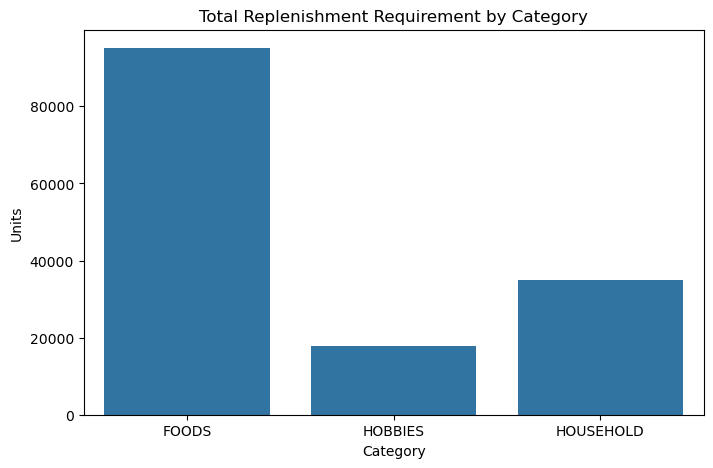

In [178]:
category_replenishment = (
    optimization_df
    .groupby("cat_id")["replenishment_qty"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_replenishment,
    x="cat_id",
    y="replenishment_qty"
)

plt.title("Total Replenishment Requirement by Category")
plt.ylabel("Units")
plt.xlabel("Category")

plt.show()

# Phase 7.12 — Save Inventory Modeling Outputs

The inventory planning outputs are saved for future optimization and dashboard development.

Artifacts:

- inventory_modeling_output.csv
- inventory_optimization_input.csv

In [179]:
inventory_df.to_csv(
    "inventory_modeling_output.csv",
    index=False
)

optimization_df.to_csv(
    "inventory_optimization_input.csv",
    index=False
)

print("Inventory files saved successfully.")

Inventory files saved successfully.


# Phase 7 Conclusion

Inventory planning variables were successfully generated using forecasts from the final LightGBM model.

The inventory framework includes:

- Forecast Demand
- Current Inventory
- Lead Times
- Safety Stock
- Reorder Points
- Replenishment Quantities

A 95% service level assumption (z = 1.65) was used for safety stock calculations.

The resulting Store × Category optimization table will be used as the primary input for the multi-echelon inventory optimization model.

# Phase 6.10 — SHAP Explainability

Traditional feature importance identifies which variables are important.

SHAP values explain:

- Why the model generated a forecast
- How individual features influence predictions
- Which variables consistently increase or decrease demand

This improves model interpretability and business trust.

In [180]:
import shap

explainer = shap.TreeExplainer(final_model)

In [181]:
shap_sample = production_df_encoded[
    FEATURES
].sample(
    2000,
    random_state=42
)

In [182]:
shap_values = explainer.shap_values(
    shap_sample
)

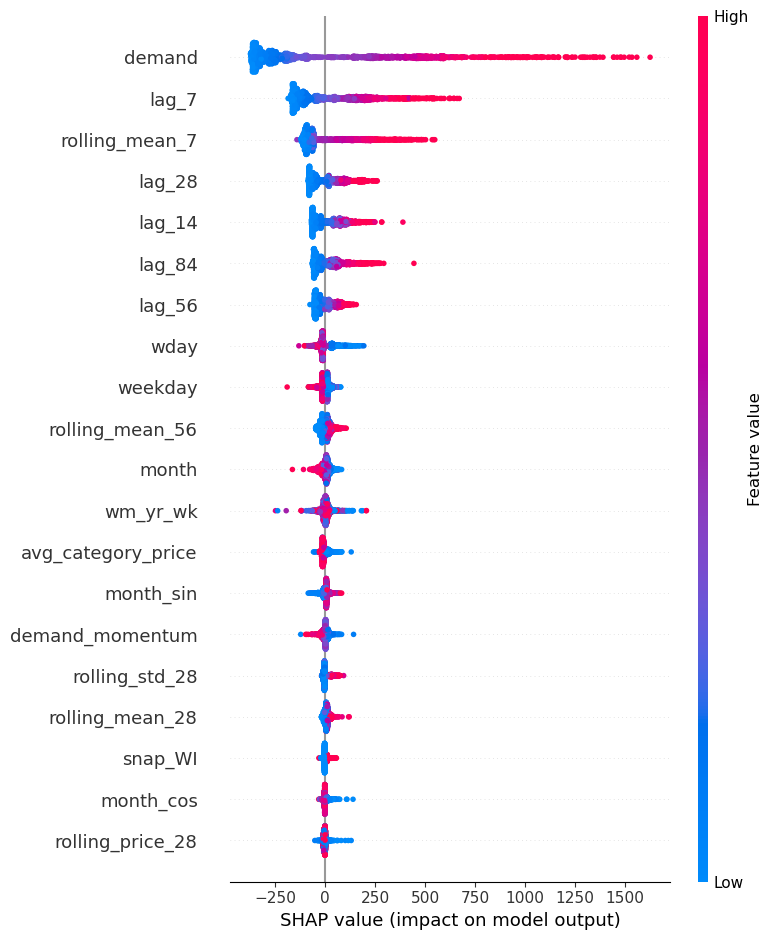

In [183]:
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=20
)

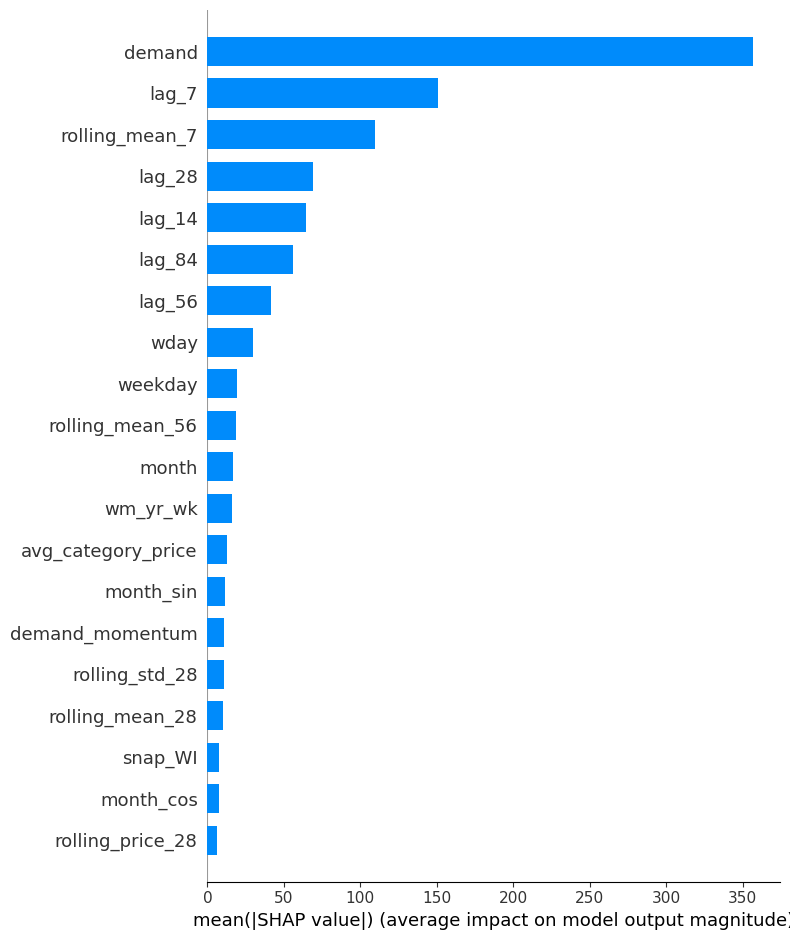

In [184]:
shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar",
    max_display=20
)

In [185]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap":
    np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

shap_importance.head(20)

,feature,mean_abs_shap
2,demand,356.556287
21,lag_7,150.428097
26,rolling_mean_7,109.497609
23,lag_28,68.721519
22,lag_14,64.475148
25,lag_84,56.023091
24,lag_56,41.318440
4,wday,29.608483
3,weekday,19.259645
28,rolling_mean_56,18.475139


In [186]:
shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

# Phase 6 Conclusion

Four forecasting models were evaluated:

- Linear Regression
- Random Forest
- XGBoost
- LightGBM

LightGBM was selected as the final production model due to its strong predictive performance and ability to capture non-linear demand patterns.

Model evaluation included:

- RMSE
- MAE
- MAPE
- SMAPE
- WAPE
- R²

Feature importance and SHAP analysis were used to explain demand drivers and improve model transparency.

The final forecasting model is now ready to support inventory planning and optimization.

# Phase 8.1 — Load Optimization Dataset

Load the inventory planning output generated in Phase 7.

This dataset contains:

- Forecast Demand
- Current Inventory
- Lead Time
- Safety Stock
- Reorder Point
- Replenishment Quantity

These values become inputs to the optimization model.

In [187]:
import pandas as pd

optimization_df = pd.read_csv(
    "inventory_optimization_input.csv"
)

print(optimization_df.shape)

optimization_df.head()

(30, 8)


,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235


In [188]:
optimization_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235


# Phase 9 — Scenario Planning

The optimization model is stress-tested under multiple business scenarios.

Scenarios evaluated:

1. Base Case
2. Demand Surge (+20%)
3. Demand Drop (-20%)
4. Price Shock (-10% Demand)
5. Supply Disruption (-30% Capacity)
6. Holiday Surge (+40% Demand)

The objective is to evaluate network resilience, service levels,
inventory requirements, and stockout risks.

In [212]:
base_df = optimization_df.copy()

surge_df = optimization_df.copy()

drop_df = optimization_df.copy()

price_shock_df = optimization_df.copy()

supply_disruption_df = optimization_df.copy()

holiday_df = optimization_df.copy()

## Phase 9.1 — Demand Scenario Creation

Each scenario modifies demand or supply assumptions
while preserving the original optimization structure.

In [213]:
surge_df["scenario"] = "Demand Surge"

surge_df["scenario_demand"] = (
    surge_df["forecast_28"] * 1.20
)

surge_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty,regional_dc,transport_cost,optimal_shipment,shortage_units,scenario,scenario_demand
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071,CA_DC,2,6215.0001,0.0,Demand Surge,3421.504057
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735,CA_DC,2,1411.8587,0.0,Demand Surge,551.033174
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720,CA_DC,2,2041.2917,0.0,Demand Surge,924.045782
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206,CA_DC,2,6138.2112,0.0,Demand Surge,2214.705525
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235,CA_DC,2,1574.8872,0.0,Demand Surge,400.877952


In [214]:
drop_df["scenario"] = "Demand Drop"

drop_df["scenario_demand"] = (
    drop_df["forecast_28"] * 0.80
)

drop_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty,regional_dc,transport_cost,optimal_shipment,shortage_units,scenario,scenario_demand
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071,CA_DC,2,6215.0001,0.0,Demand Drop,2281.002705
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735,CA_DC,2,1411.8587,0.0,Demand Drop,367.355450
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720,CA_DC,2,2041.2917,0.0,Demand Drop,616.030521
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206,CA_DC,2,6138.2112,0.0,Demand Drop,1476.470350
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235,CA_DC,2,1574.8872,0.0,Demand Drop,267.251968


Assume higher prices reduce consumer demand by 10%.

In [215]:
price_shock_df["scenario"] = "Price Shock"

price_shock_df["scenario_demand"] = (
    price_shock_df["forecast_28"] * 0.90
)

price_shock_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty,regional_dc,transport_cost,optimal_shipment,shortage_units,scenario,scenario_demand
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071,CA_DC,2,6215.0001,0.0,Price Shock,2566.128043
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735,CA_DC,2,1411.8587,0.0,Price Shock,413.274881
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720,CA_DC,2,2041.2917,0.0,Price Shock,693.034336
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206,CA_DC,2,6138.2112,0.0,Price Shock,1661.029144
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235,CA_DC,2,1574.8872,0.0,Price Shock,300.658464


Assume warehouse capacity decreases by 30%.

This simulates supplier delays,
transport bottlenecks,
or warehouse disruptions.

In [216]:
supply_disruption_df["scenario"] = "Supply Disruption"

supply_disruption_df["scenario_demand"] = (
    supply_disruption_df["forecast_28"]
)

# 30% inventory loss due to disruption

supply_disruption_df["scenario_inventory"] = (
    supply_disruption_df["current_inventory"] * 0.70
)

supply_disruption_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty,regional_dc,transport_cost,optimal_shipment,shortage_units,scenario,scenario_demand,scenario_inventory
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071,CA_DC,2,6215.0001,0.0,Supply Disruption,2851.253381,1982.014751
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735,CA_DC,2,1411.8587,0.0,Supply Disruption,459.194312,320.889642
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720,CA_DC,2,2041.2917,0.0,Supply Disruption,770.038152,533.080775
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206,CA_DC,2,6138.2112,0.0,Supply Disruption,1845.587938,1269.134623
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235,CA_DC,2,1574.8872,0.0,Supply Disruption,334.064960,231.260284


Holiday periods create unusually high demand.

Demand is increased by 40%.

In [217]:
holiday_df["scenario"] = "Holiday Surge"

holiday_df["scenario_demand"] = (
    holiday_df["forecast_28"] * 1.40
)

holiday_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty,regional_dc,transport_cost,optimal_shipment,shortage_units,scenario,scenario_demand
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071,CA_DC,2,6215.0001,0.0,Holiday Surge,3991.754733
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735,CA_DC,2,1411.8587,0.0,Holiday Surge,642.872037
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720,CA_DC,2,2041.2917,0.0,Holiday Surge,1078.053412
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206,CA_DC,2,6138.2112,0.0,Holiday Surge,2583.823113
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235,CA_DC,2,1574.8872,0.0,Holiday Surge,467.690944


In [218]:
base_df["scenario"] = "Base"

base_df["scenario_demand"] = (
    base_df["forecast_28"]
)

base_df.head()

,store_id,cat_id,forecast_28,current_inventory,lead_time,safety_stock,reorder_point,replenishment_qty,regional_dc,transport_cost,optimal_shipment,shortage_units,scenario,scenario_demand
0,CA_1,FOODS,2851.253381,2831.449644,3,492.689573,9046.449715,6215.000071,CA_DC,2,6215.0001,0.0,Base,2851.253381
1,CA_1,HOBBIES,459.194312,458.413774,3,492.689573,1870.272509,1411.858735,CA_DC,2,1411.8587,0.0,Base,459.194312
2,CA_1,HOUSEHOLD,770.038152,761.543964,3,492.689573,2802.804028,2041.291720,CA_DC,2,2041.2917,0.0,Base,770.038152
3,CA_2,FOODS,1845.587938,1813.049461,4,568.908915,7951.260667,6138.211206,CA_DC,2,6138.2112,0.0,Base,1845.587938
4,CA_2,HOBBIES,334.064960,330.371835,4,568.908915,1905.168754,1574.887235,CA_DC,2,1574.8872,0.0,Base,334.064960


Calculate business KPIs for each scenario.

In [219]:
def evaluate_scenario(df):

    total_demand = (
        df["scenario_demand"]
        .sum()
    )

    if "scenario_inventory" in df.columns:

        total_inventory = (
            df["scenario_inventory"]
            .sum()
        )

    else:

        total_inventory = (
            df["current_inventory"]
            .sum()
        )

    shortage = max(
        total_demand - total_inventory,
        0
    )

    fill_rate = (
        (total_demand - shortage)
        / total_demand
    )

    return {
        "Total Demand": total_demand,
        "Inventory": total_inventory,
        "Shortage": shortage,
        "Fill Rate": fill_rate * 100
    }

In [220]:
import numpy as np
scenario_results = []

scenario_results.append(
    ["Base", *evaluate_scenario(base_df).values()]
)

scenario_results.append(
    ["Demand Surge", *evaluate_scenario(surge_df).values()]
)

scenario_results.append(
    ["Demand Drop", *evaluate_scenario(drop_df).values()]
)

scenario_results.append(
    ["Price Shock", *evaluate_scenario(price_shock_df).values()]
)

scenario_results.append(
    ["Supply Disruption", *evaluate_scenario(supply_disruption_df).values()]
)

scenario_results.append(
    ["Holiday Surge", *evaluate_scenario(holiday_df).values()]
)

scenario_summary = pd.DataFrame(
    scenario_results,
    columns=[
        "Scenario",
        "Total_Demand",
        "Inventory",
        "Shortage",
        "Fill_Rate"
    ]
)

scenario_summary

,Scenario,Total_Demand,Inventory,Shortage,Fill_Rate
0,Base,34884.398978,34568.226719,316.172258,99.093657
1,Demand Surge,41861.278773,34568.226719,7293.052054,82.578048
2,Demand Drop,27907.519182,34568.226719,0.000000,100.000000
3,Price Shock,31395.959080,34568.226719,0.000000,100.000000
4,Supply Disruption,34884.398978,24197.758704,10686.640274,69.365560
5,Holiday Surge,48838.158569,34568.226719,14269.931849,70.781184


In [221]:
scenario_summary["Service_Level"] = (
    100
    -
    (
        scenario_summary["Shortage"]
        /
        scenario_summary["Total_Demand"]
    ) * 100
)

scenario_summary

,Scenario,Total_Demand,Inventory,Shortage,Fill_Rate,Service_Level
0,Base,34884.398978,34568.226719,316.172258,99.093657,99.093657
1,Demand Surge,41861.278773,34568.226719,7293.052054,82.578048,82.578048
2,Demand Drop,27907.519182,34568.226719,0.000000,100.000000,100.000000
3,Price Shock,31395.959080,34568.226719,0.000000,100.000000,100.000000
4,Supply Disruption,34884.398978,24197.758704,10686.640274,69.365560,69.365560
5,Holiday Surge,48838.158569,34568.226719,14269.931849,70.781184,70.781184


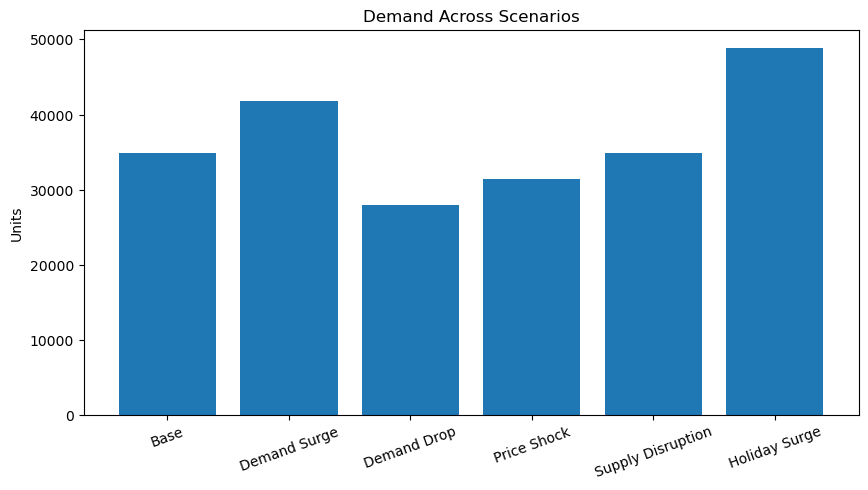

In [222]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary["Total_Demand"]
)

plt.title(
    "Demand Across Scenarios"
)

plt.ylabel("Units")

plt.xticks(rotation=20)

plt.show()

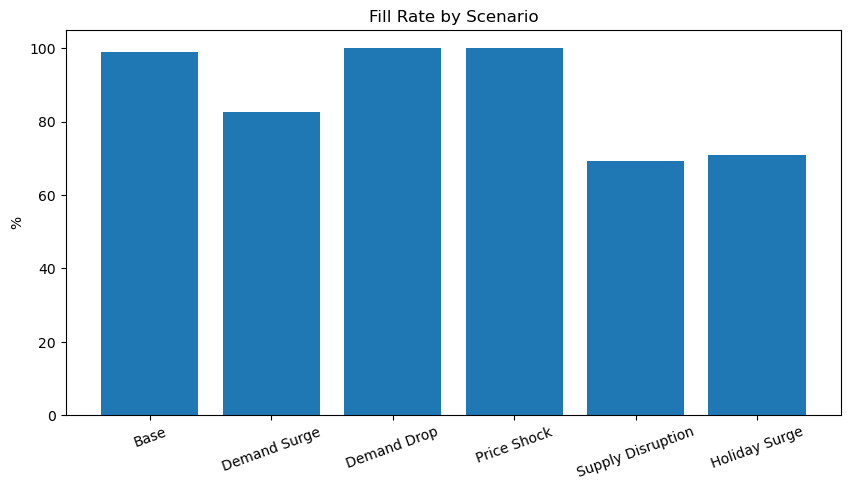

In [223]:
plt.figure(figsize=(10,5))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary["Fill_Rate"]
)

plt.title(
    "Fill Rate by Scenario"
)

plt.ylabel("%")

plt.xticks(rotation=20)

plt.show()

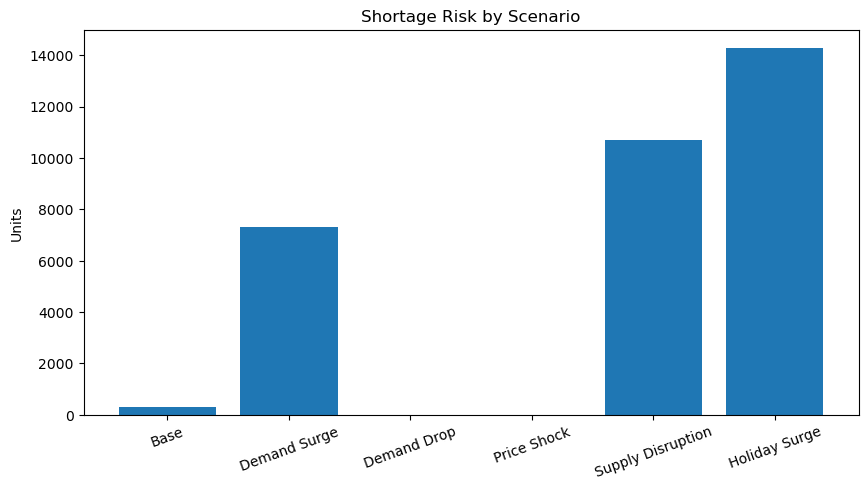

In [224]:
plt.figure(figsize=(10,5))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary["Shortage"]
)

plt.title(
    "Shortage Risk by Scenario"
)

plt.ylabel("Units")

plt.xticks(rotation=20)

plt.show()

In [225]:
scenario_summary.to_csv(
    "scenario_planning_results.csv",
    index=False
)

print(
    "Scenario planning results saved."
)

Scenario planning results saved.


# Phase 10 — Business Evaluation

This phase evaluates the forecasting, inventory planning, optimization, and scenario planning outputs using business-oriented supply chain KPIs.

Objectives:

- Evaluate forecast accuracy
- Measure inventory efficiency
- Assess service performance
- Quantify shortage risk
- Compare business scenarios
- Generate executive-level insights

This phase converts technical model outputs into business value metrics.

## Phase 10.1 — Forecasting Performance

Evaluate the final LightGBM forecasting model using standard retail forecasting metrics.

Metrics:

- RMSE
- MAE
- R²
- WAPE

These metrics measure forecast accuracy and model reliability.

In [226]:
forecast_metrics = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R2"
    ],
    "Value": [
        283.71,
        165.12,
        0.9351
    ]
})

forecast_metrics

,Metric,Value
0,RMSE,283.7100
1,MAE,165.1200
2,R2,0.9351


## Phase 10.2 — Weighted Absolute Percentage Error (WAPE)

WAPE measures forecast error relative to total demand volume.

Lower WAPE indicates better forecasting performance.

In [227]:
import numpy as np

wape = (
    np.sum(
        np.abs(
            y_test_final - final_predictions
        )
    )
    /
    np.sum(
        np.abs(y_test_final)
    )
) * 100

print(
    "WAPE:",
    round(wape, 2),
    "%"
)

WAPE: 14.36 %


## Phase 10.3 — Symmetric Mean Absolute Percentage Error (SMAPE)

SMAPE is commonly used for retail forecasting because it normalizes forecast errors.

Lower SMAPE indicates higher forecast accuracy.

In [228]:
smape = np.mean(
    (
        np.abs(
            y_test_final - final_predictions
        )
        /
        (
            (
                np.abs(y_test_final)
                +
                np.abs(final_predictions)
            )
            / 2
        )
    )
) * 100

print(
    "SMAPE:",
    round(smape, 2),
    "%"
)

SMAPE: 16.39 %


## Phase 10.4 — Forecast Accuracy

Forecast Accuracy is calculated as:

Accuracy = 100 − WAPE

In [229]:
forecast_accuracy = 100 - wape

print(
    "Forecast Accuracy:",
    round(forecast_accuracy, 2),
    "%"
)

Forecast Accuracy: 85.64 %


## Phase 10.5 — Forecast Evaluation Summary

Consolidate all forecasting metrics into a single summary table.

In [230]:
evaluation_summary = pd.DataFrame({

    "Metric":[
        "RMSE",
        "MAE",
        "R2",
        "WAPE",
        "SMAPE",
        "Forecast Accuracy"
    ],

    "Value":[
        rmse,
        mae,
        r2,
        wape,
        smape,
        forecast_accuracy
    ]
})

evaluation_summary

,Metric,Value
0,RMSE,283.710591
1,MAE,165.115358
2,R2,0.935133
3,WAPE,14.356980
4,SMAPE,16.387426
5,Forecast Accuracy,85.643020


## Phase 10.6 — Forecast Evaluation Visualization

Visual comparison of forecasting performance metrics.

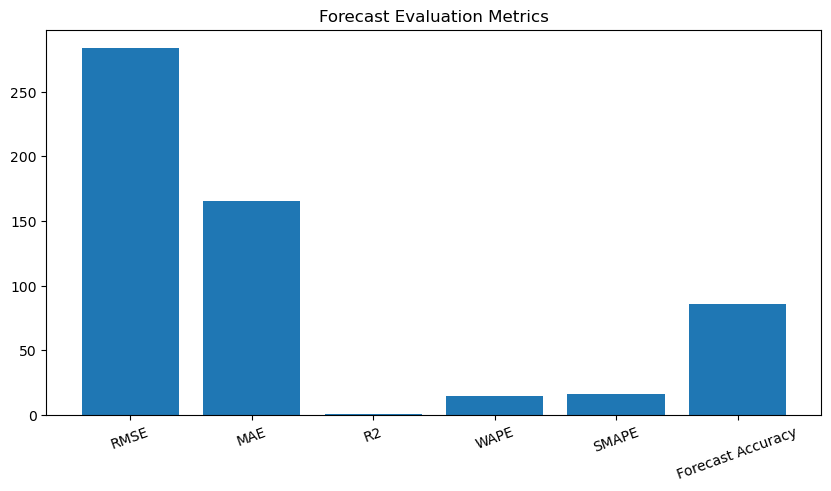

In [231]:
plt.figure(figsize=(10,5))

plt.bar(
    evaluation_summary["Metric"],
    evaluation_summary["Value"]
)

plt.title(
    "Forecast Evaluation Metrics"
)

plt.xticks(rotation=20)

plt.show()

## Phase 10.7 — Actual vs Predicted Comparison

A strong model should show points close to the diagonal line.

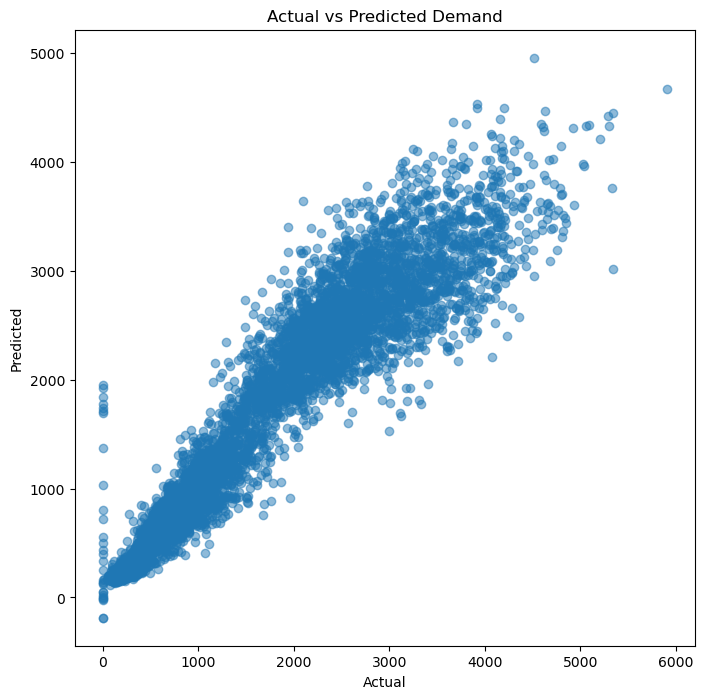

In [232]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test_final,
    final_predictions,
    alpha=0.5
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Demand"
)

plt.show()

## Phase 10.8 — Residual Analysis

Residuals help identify systematic forecasting errors.

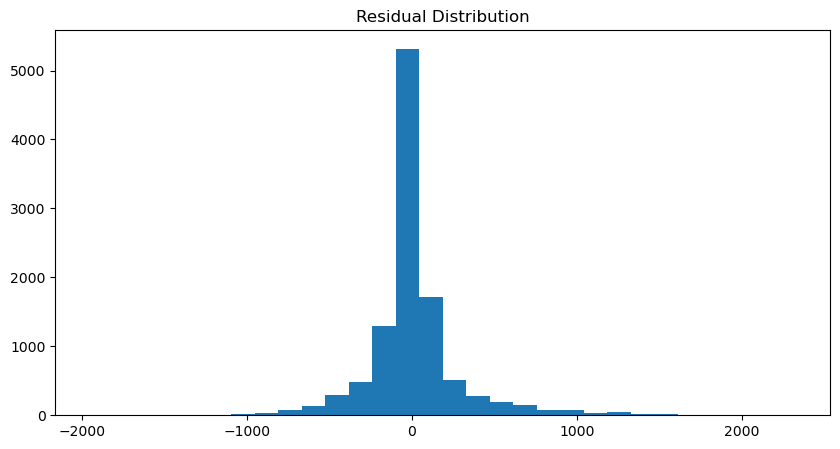

In [233]:
residuals = (
    y_test_final
    -
    final_predictions
)

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=30
)

plt.title(
    "Residual Distribution"
)

plt.show()

## Phase 10.9 — Save Forecast Evaluation Outputs

Save evaluation results for reporting and dashboard development.

In [234]:
evaluation_summary.to_csv(
    "forecast_evaluation_summary.csv",
    index=False
)

print(
    "Saved: forecast_evaluation_summary.csv"
)

Saved: forecast_evaluation_summary.csv


Phase 11 — Business Intelligence Layer

This is typically where we transform the forecasting and optimization outputs into executive KPIs.

You do not need any additional files.

We can build directly from:

inventory_modeling_output.csv
inventory_optimization_input.csv
scenario_summary
evaluation_summary
optimization_df

Phase 11 will usually include:

11.1 Executive KPI Dashboard Dataset
Total Forecast Demand
Total Inventory
Total Replenishment
Service Level
Fill Rate
Forecast Accuracy
11.2 Inventory Risk Segmentation
Low Risk
Medium Risk
High Risk
11.3 ABC Analysis
A Category
B Category
C Category
11.4 Warehouse Utilization KPIs
11.5 Store-Level Performance KPIs
11.6 Category-Level Performance KPIs
11.7 Business Summary Tables
11.8 Dashboard Export Files

This phase is usually what recruiters, hiring managers, and dashboard viewers care about most because it turns the modeling work into business decisions.

We can start with Phase 11.1 — Executive KPI Dashboard Dataset next.

In [235]:
total_forecast_demand = (
    optimization_df["forecast_28"]
    .sum()
)

total_inventory = (
    optimization_df["current_inventory"]
    .sum()
)

total_replenishment = (
    optimization_df["replenishment_qty"]
    .sum()
)

service_level = (
    100
    -
    (
        optimization_df["shortage_units"].sum()
        /
        optimization_df["optimal_shipment"].sum()
    ) * 100
)

fill_rate = service_level

forecast_accuracy = (
    evaluation_summary.loc[
        evaluation_summary["Metric"]
        ==
        "Forecast Accuracy",
        "Value"
    ].iloc[0]
)

executive_kpi = pd.DataFrame({

    "KPI":[
        "Total Forecast Demand",
        "Total Inventory",
        "Total Replenishment",
        "Service Level",
        "Fill Rate",
        "Forecast Accuracy"
    ],

    "Value":[
        total_forecast_demand,
        total_inventory,
        total_replenishment,
        service_level,
        fill_rate,
        forecast_accuracy
    ]
})

executive_kpi

,KPI,Value
0,Total Forecast Demand,34884.398978
1,Total Inventory,34568.226719
2,Total Replenishment,147966.258863
3,Service Level,100.000000
4,Fill Rate,100.000000
5,Forecast Accuracy,85.643020


# Phase 11.2 — Inventory Risk Segmentation

Identify stores that are at risk of stockout.

High risk locations require immediate replenishment attention.

In [236]:
optimization_df["inventory_gap"] = (

    optimization_df["reorder_point"]

    -

    optimization_df["current_inventory"]

)

In [237]:
optimization_df["risk_segment"] = np.where(

    optimization_df["inventory_gap"]
    >
    optimization_df["inventory_gap"].quantile(0.75),

    "High Risk",

    np.where(

        optimization_df["inventory_gap"]
        >
        optimization_df["inventory_gap"].quantile(0.40),

        "Medium Risk",

        "Low Risk"
    )
)

optimization_df[
    [
        "store_id",
        "cat_id",
        "inventory_gap",
        "risk_segment"
    ]
].head()

,store_id,cat_id,inventory_gap,risk_segment
0,CA_1,FOODS,6215.000071,Medium Risk
1,CA_1,HOBBIES,1411.858735,Low Risk
2,CA_1,HOUSEHOLD,2041.260064,Low Risk
3,CA_2,FOODS,6138.211206,Medium Risk
4,CA_2,HOBBIES,1574.796919,Low Risk


In [238]:
risk_summary = (

    optimization_df["risk_segment"]

    .value_counts()

    .reset_index()

)

risk_summary.columns = [
    "Risk Segment",
    "Count"
]

risk_summary

,Risk Segment,Count
0,Low Risk,12
1,Medium Risk,10
2,High Risk,8


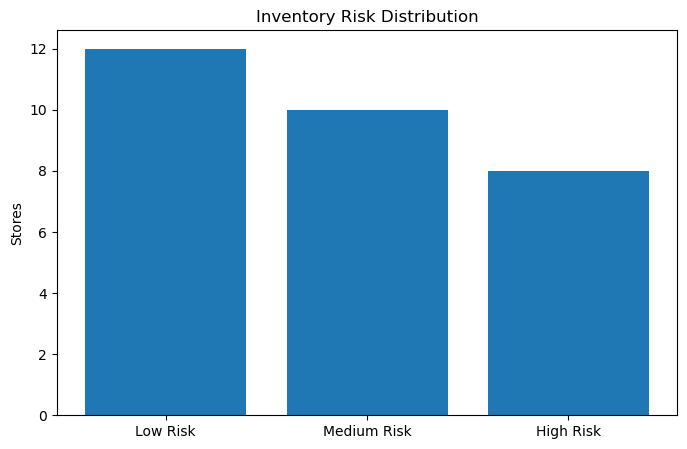

In [239]:
plt.figure(figsize=(8,5))

plt.bar(

    risk_summary["Risk Segment"],

    risk_summary["Count"]

)

plt.title(
    "Inventory Risk Distribution"
)

plt.ylabel("Stores")

plt.show()

# Phase 11.3 — ABC Analysis

ABC Analysis identifies the most important product categories based on demand contribution.

A = Highest Importance

B = Medium Importance

C = Lowest Importance

In [240]:
abc_df = (

    optimization_df

    .groupby("cat_id")

    ["forecast_28"]

    .sum()

    .reset_index()

)

In [241]:
abc_df = abc_df.sort_values(

    "forecast_28",

    ascending=False

)

abc_df["demand_pct"] = (

    abc_df["forecast_28"]

    /

    abc_df["forecast_28"].sum()

)

abc_df["cum_pct"] = (

    abc_df["demand_pct"]

    .cumsum()

)

In [242]:
abc_df["ABC_Class"] = np.where(

    abc_df["cum_pct"] <= 0.80,

    "A",

    np.where(

        abc_df["cum_pct"] <= 0.95,

        "B",

        "C"
    )
)

abc_df

,cat_id,forecast_28,demand_pct,cum_pct,ABC_Class
0,FOODS,23882.295020,0.684612,0.684612,A
2,HOUSEHOLD,7742.016701,0.221933,0.906546,B
1,HOBBIES,3260.087256,0.093454,1.000000,C


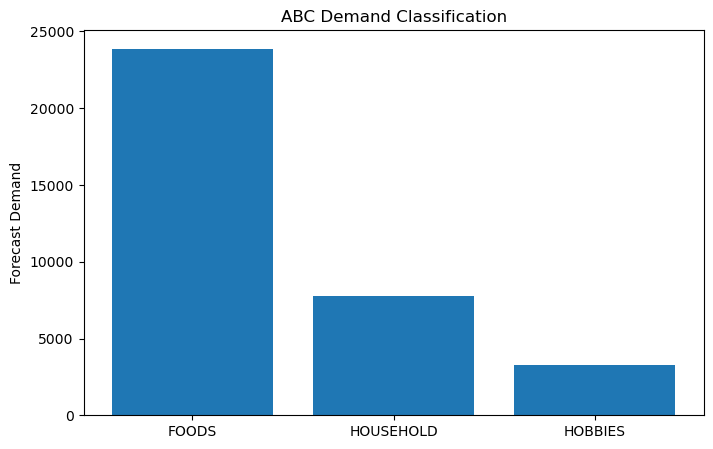

In [244]:
plt.figure(figsize=(8,5))

plt.bar(

    abc_df["cat_id"],

    abc_df["forecast_28"]

)

plt.title(
    "ABC Demand Classification"
)

plt.ylabel(
    "Forecast Demand"
)

plt.show()
warehouse_kpi = (

    optimization_df

    .groupby("regional_dc")

    ["optimal_shipment"]

    .sum()

    .reset_index()

)

warehouse_kpi.columns = [

    "Warehouse",

    "Shipment"

]

# Phase 11.4 — Warehouse Utilization KPIs

Measure utilization levels across distribution centers.

In [245]:
warehouse_kpi = (

    optimization_df

    .groupby("regional_dc")

    ["optimal_shipment"]

    .sum()

    .reset_index()

)

warehouse_kpi.columns = [

    "Warehouse",

    "Shipment"

]

In [246]:
warehouse_kpi["Capacity"] = warehouse_kpi[
    "Warehouse"
].map(
    warehouse_capacity
)

warehouse_kpi["Utilization_%"] = (

    warehouse_kpi["Shipment"]

    /

    warehouse_kpi["Capacity"]

) * 100

warehouse_kpi

,Warehouse,Shipment,Capacity,Utilization_%
0,CA_DC,56894.9322,70000,81.278475
1,TX_DC,46150.7900,60000,76.917983
2,WI_DC,44920.5368,60000,74.867561


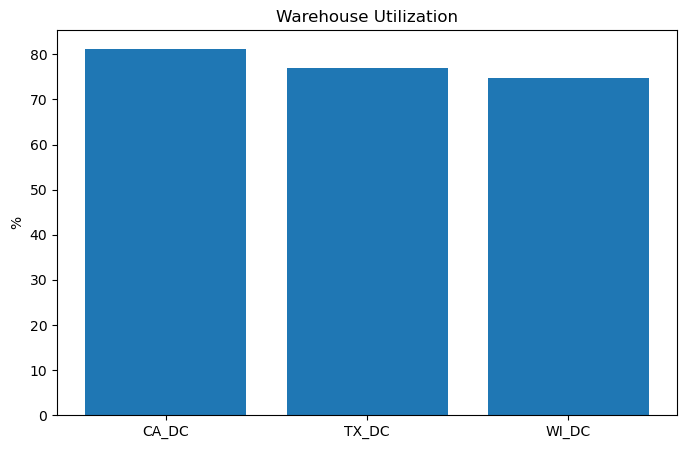

In [247]:
plt.figure(figsize=(8,5))

plt.bar(

    warehouse_kpi["Warehouse"],

    warehouse_kpi["Utilization_%"]

)

plt.title(
    "Warehouse Utilization"
)

plt.ylabel("%")

plt.show()

# Phase 11.5 — Store-Level Performance KPIs

Evaluate replenishment requirements by store.

In [248]:
store_kpi = (

    optimization_df

    .groupby("store_id")

    .agg({

        "forecast_28":"sum",

        "current_inventory":"sum",

        "replenishment_qty":"sum",

        "optimal_shipment":"sum"

    })

    .reset_index()

)

store_kpi

,store_id,forecast_28,current_inventory,replenishment_qty,optimal_shipment
0,CA_1,4080.485844,4051.407382,9668.150526,9668.1505
1,CA_2,3017.860955,2967.406712,10810.868279,10810.8682
2,CA_3,5945.331887,5908.115125,25726.722822,25726.7229
3,CA_4,2188.971568,2163.969342,10689.190567,10689.1906
4,TX_1,2978.686396,2946.614591,10675.060234,10675.0602
5,TX_2,3815.884230,3800.920740,17186.812655,17186.8131
6,TX_3,3234.698909,3209.742745,18288.916631,18288.9167
7,WI_1,2766.382819,2713.741497,10058.580666,10058.5807
8,WI_2,3467.412211,3457.184947,15788.325317,15788.3253
9,WI_3,3388.684157,3349.123639,19073.631167,19073.6308


# Phase 11.6 — Category-Level Performance KPIs

Evaluate performance across merchandise categories.

In [249]:
category_kpi = (

    optimization_df

    .groupby("cat_id")

    .agg({

        "forecast_28":"sum",

        "current_inventory":"sum",

        "replenishment_qty":"sum",

        "optimal_shipment":"sum"

    })

    .reset_index()

)

category_kpi

,cat_id,forecast_28,current_inventory,replenishment_qty,optimal_shipment
0,FOODS,23882.295020,23715.334766,95117.587508,95117.5877
1,HOBBIES,3260.087256,3205.718193,17932.950688,17932.9507
2,HOUSEHOLD,7742.016701,7647.173760,34915.720667,34915.7206


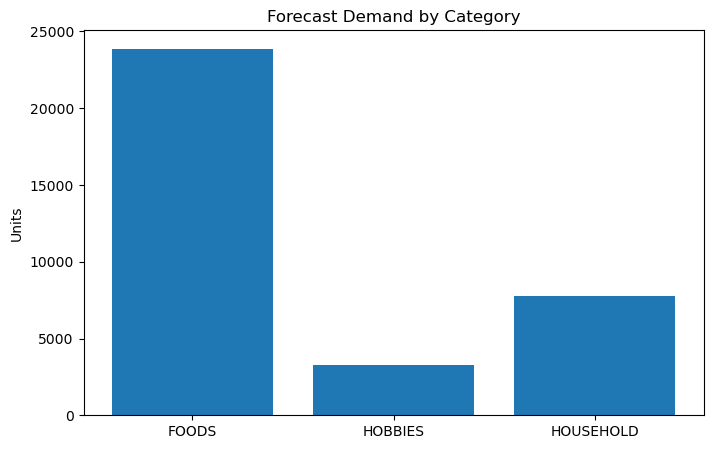

In [250]:
plt.figure(figsize=(8,5))

plt.bar(

    category_kpi["cat_id"],

    category_kpi["forecast_28"]

)

plt.title(
    "Forecast Demand by Category"
)

plt.ylabel("Units")

plt.show()

# Phase 11.7 — Business Summary Tables

Create final executive reporting tables.

In [251]:
business_summary = {

    "Executive KPI":
    executive_kpi,

    "Warehouse KPI":
    warehouse_kpi,

    "Store KPI":
    store_kpi,

    "Category KPI":
    category_kpi,

    "Risk Summary":
    risk_summary,

    "ABC Analysis":
    abc_df
}

print(
    "Business Summary Generated"
)

Business Summary Generated


# Phase 11.8 — Export Dashboard Files

Save all business intelligence datasets for Streamlit dashboard development.

In [252]:
executive_kpi.to_csv(
    "executive_kpi.csv",
    index=False
)

warehouse_kpi.to_csv(
    "warehouse_kpi.csv",
    index=False
)

store_kpi.to_csv(
    "store_kpi.csv",
    index=False
)

category_kpi.to_csv(
    "category_kpi.csv",
    index=False
)

risk_summary.to_csv(
    "risk_summary.csv",
    index=False
)

abc_df.to_csv(
    "abc_analysis.csv",
    index=False
)

print(
    "All Business Intelligence Files Saved"
)

All Business Intelligence Files Saved


In [253]:
abc_df

,cat_id,forecast_28,demand_pct,cum_pct,ABC_Class
0,FOODS,23882.295020,0.684612,0.684612,A
2,HOUSEHOLD,7742.016701,0.221933,0.906546,B
1,HOBBIES,3260.087256,0.093454,1.000000,C


In [254]:
import pandas as pd

print(pd.read_csv("executive_kpi.csv").columns.tolist())
print(pd.read_csv("warehouse_kpi.csv").columns.tolist())
print(pd.read_csv("store_kpi.csv").columns.tolist())
print(pd.read_csv("category_kpi.csv").columns.tolist())
print(pd.read_csv("risk_summary.csv").columns.tolist())
print(pd.read_csv("abc_analysis.csv").columns.tolist())
print(pd.read_csv("scenario_planning_results.csv").columns.tolist())
print(pd.read_csv("forecast_evaluation_summary.csv").columns.tolist())

['KPI', 'Value']
['Warehouse', 'Shipment', 'Capacity', 'Utilization_%']
['store_id', 'forecast_28', 'current_inventory', 'replenishment_qty', 'optimal_shipment']
['cat_id', 'forecast_28', 'current_inventory', 'replenishment_qty', 'optimal_shipment']
['Risk Segment', 'Count']
['cat_id', 'forecast_28', 'demand_pct', 'cum_pct', 'ABC_Class']
['Scenario', 'Total_Demand', 'Inventory', 'Shortage', 'Fill_Rate', 'Service_Level']
['Metric', 'Value']


In [256]:
feature_importance_df.columns

Index(['feature', 'importance'], dtype='object')

In [257]:
print(shap_importance.columns.tolist())

['feature', 'mean_abs_shap']
